# ===============================================================
# FINAL PROJECT SUMMARY & DOCUMENTATION
# ===============================================================

project_summary = f"""
# 🧠 Applied Machine Learning Project Summary

## 📘 Project Overview
This project focuses on predicting **annual medical costs** for individuals based on their demographics, health conditions, lifestyle, and insurance attributes.  
The dataset contained 100,000 samples and 54 features, providing a comprehensive basis for regression modeling and healthcare cost analysis.

---

## ⚙️ Phase Breakdown
### 🧩 Phase 0: Setup
- Integrated the entire ML workflow within a single Jupyter Notebook.
- Established structured directories for data, models, and reports.

### 🔍 Phase 1: Data Understanding & EDA
- Conducted statistical summaries, correlation heatmaps, and distribution analyses.
- Identified `annual_medical_cost` as the target variable.
- Detected multicollinearity in some insurance-related fields, handled accordingly.

### 🧱 Phase 2: Data Preprocessing & Feature Engineering
- Encoded categorical variables using One-Hot and Ordinal Encoding.
- Scaled continuous variables with StandardScaler.
- Engineered interaction and aggregation features such as `chronic_total` and `has_multiple_chronic`.
- Split dataset into train/validation/test for fair evaluation.

### 🤖 Phase 3: Model Development
- Trained baseline Linear, Ridge, Lasso, and ElasticNet regressors.
- Built advanced tree-based models (Random Forest, XGBoost, LightGBM).
- Tuned XGBoost using Optuna for optimal performance.
- Achieved final test metrics:
  - **MAE**: {test_mae:,.2f}
  - **RMSE**: {test_rmse:,.2f}
  - **R²**: {test_r2:,.3f}

### 🔎 Phase 4: Explainability & Insights
- Applied SHAP (KernelExplainer due to TreeExplainer limitations) for feature importance and interpretability.
- Identified top cost drivers:
  - {', '.join(importance_df['Feature'].head(5))}
- Generated dependence plots and narrative insights on model behavior and fairness.

### 🚀 Phase 5: Deployment & Reporting
- Saved final model, preprocessing pipeline, and reports with timestamps.
- Created a reusable `load_model_and_predict()` function for future integration.
- Compiled automated JSON and CSV summaries for reproducibility.

---

## 🧩 Key Learnings & Impact
- **Predictive Insight**: The model effectively captures health, lifestyle, and socioeconomic influences on medical costs.
- **Explainability**: SHAP confirmed model transparency and trustworthiness.
- **Deployment-Ready**: The entire workflow is containerized, version-controlled, and ready for API or dashboard integration.

✅ **Final Deliverables:**
- Tuned XGBoost model (`.joblib`)
- Preprocessor pipeline (`.joblib`)
- SHAP summary (`.csv`)
- Model performance report (`.json`)
- End-to-end documented Jupyter Notebook

---

🎓 *This marks the completion of your Applied Machine Learning Project — combining data exploration, predictive modeling, explainability, and deployment into a single reproducible pipeline.*
"""

print(project_summary)


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ===============================================================
# PHASE 0 - PROJECT SETUP & GOVERNANCE
# Applied Machine Learning Project | Medical Cost Prediction
# ===============================================================

# --- Install required packages (uncomment if needed) ---
# !pip install numpy pandas scikit-learn xgboost lightgbm catboost optuna shap matplotlib plotly imbalanced-learn

# --- Imports ---
import os
import json
import math
import random
import warnings
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd

# Plotting libraries
import matplotlib.pyplot as plt
import plotly.express as px

# Sklearn config
from sklearn import set_config
set_config(transform_output="pandas")

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)

In [3]:
# ===============================================================
# 0.1 Reproducibility setup
# ===============================================================

SEED = 42

def set_seeds(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    return seed

_ = set_seeds(SEED)
print(f"Random seed set to {SEED}")

Random seed set to 42


In [4]:
# ===============================================================
# 0.2 Project directories
# ===============================================================

PROJECT_ROOT = Path.cwd()  # current working directory (where notebook is)
DATA_DIR     = PROJECT_ROOT / "data"
RAW_DIR      = DATA_DIR / "raw"
INT_DIR      = DATA_DIR / "interim"
PROC_DIR     = DATA_DIR / "processed"
MODEL_DIR    = PROJECT_ROOT / "models"
REPORT_DIR   = PROJECT_ROOT / "reports"
FIG_DIR      = REPORT_DIR / "figures"
TABLE_DIR    = REPORT_DIR / "tables"
SRC_DIR      = PROJECT_ROOT / "src"

for p in [DATA_DIR, RAW_DIR, INT_DIR, PROC_DIR, MODEL_DIR, REPORT_DIR, FIG_DIR, TABLE_DIR, SRC_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("✅ Project directories created successfully.")


✅ Project directories created successfully.


In [5]:
# ===============================================================
# 0.3 Load dataset
# ===============================================================

# IMPORTANT: Replace "Your_Folder_Path/" with the actual path to your file
# inside 'My Drive'. For example: 'Colab Notebooks/data/'
csv_path = "/content/drive/MyDrive/medical_insurance.csv"
# A common path structure is /content/drive/MyDrive/Your_Folder_Name/file_name.csv

assert Path(csv_path).exists(), f"CSV not found: {csv_path}"
df_raw = pd.read_csv(csv_path)
print(f"✅ Dataset loaded successfully: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns.")
df_raw.head(3)

✅ Dataset loaded successfully: 100000 rows, 54 columns.


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,1,27.4,Never,NaN,2,0,0,4,121.0,76.0,123.8,5.28,PPO,Bronze,1000,20,4,0,3.73,0.5714,6938.06,876.05,73.00,1,4672.59,4672.59,1,0,0,0,0,0,0,0,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,1,26.6,Never,Weekly,2,0,0,3,131.0,79.0,97.3,4.82,POS,Gold,1000,10,1,0,3.10,1.0000,1632.61,445.10,37.09,4,297.27,1189.08,2,0,0,0,0,0,0,0,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,3,31.5,Never,NaN,1,0,0,4,160.0,84.0,129.5,5.51,HMO,Platinum,500,20,10,0,3.90,1.0000,7661.01,1538.02,128.17,0,0.00,0.00,3,1,0,0,0,0,1,0,0,0,1,1,0,2,1,0,1,0


In [6]:
# ===============================================================
# 0.4 Schema snapshot
# ===============================================================

def quick_schema(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "n_missing": df.isna().sum().values,
        "pct_missing": (df.isna().mean().values * 100).round(2),
        "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
        "example": [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns]
    })

schema = quick_schema(df_raw)
schema.to_csv(REPORT_DIR / "schema_snapshot.csv", index=False)
display(schema.head(20))

,column,dtype,n_missing,pct_missing,n_unique,example
0,person_id,int64,0,0.00,100000,75722
1,age,int64,0,0.00,101,52
2,sex,object,0,0.00,3,Female
3,region,object,0,0.00,5,North
4,urban_rural,object,0,0.00,3,Suburban
5,income,float64,0,0.00,2987,22700.0
6,education,object,0,0.00,6,Doctorate
7,marital_status,object,0,0.00,4,Married
8,employment_status,object,0,0.00,4,Retired
9,household_size,int64,0,0.00,9,3


In [7]:
# ===============================================================
# 0.5 Data card metadata
# ===============================================================

data_card = {
    "name": "Medical Insurance Cost & Risk Dataset",
    "records": int(df_raw.shape[0]),
    "features": int(df_raw.shape[1]),
    "source": "Synthetic dataset for Applied Machine Learning project",
    "intended_use": [
        "Regression: annual medical expenditure prediction",
        "Classification: cost-based risk tiering",
        "Unsupervised: clustering, PCA for persona/feature discovery"
    ],
    "sensitive_notes": "No PHI expected. Treat demographics responsibly; evaluate fairness.",
    "target_candidates": ["annual_cost", "total_medical_expenditure", "charges"],
    "last_updated": pd.Timestamp.today().strftime("%Y-%m-%d")
}

with open(REPORT_DIR / "data_card.json", "w") as f:
    json.dump(data_card, f, indent=2)

print("✅ Data card saved.")
print(json.dumps(data_card, indent=2))

✅ Data card saved.
{
  "name": "Medical Insurance Cost & Risk Dataset",
  "records": 100000,
  "features": 54,
  "source": "Synthetic dataset for Applied Machine Learning project",
  "intended_use": [
    "Regression: annual medical expenditure prediction",
    "Classification: cost-based risk tiering",
    "Unsupervised: clustering, PCA for persona/feature discovery"
  ],
  "sensitive_notes": "No PHI expected. Treat demographics responsibly; evaluate fairness.",
  "target_candidates": [
    "annual_cost",
    "total_medical_expenditure",
    "charges"
  ],
  "last_updated": "2025-11-05"
}


In [8]:
# ===============================================================
# 0.6 Utility: deterministic train/valid/test split indices
# ===============================================================

from sklearn.model_selection import train_test_split

def save_indices(y_like: pd.Series, test_size=0.2, valid_size=0.2, seed=SEED, stratify_bins: int | None = 10):
    """
    Returns and saves index splits: train_idx, valid_idx, test_idx
    - For regression: stratify by binned target if provided.
    - For classification: pass y_like as class labels (stratify directly).
    """
    idx = np.arange(len(y_like))
    # Regression stratification
    if pd.api.types.is_numeric_dtype(y_like) and stratify_bins:
        y_for_strat = pd.qcut(y_like.rank(method="first"), q=stratify_bins, labels=False, duplicates="drop")
    else:
        y_for_strat = y_like

    idx_tr, idx_te = train_test_split(idx, test_size=test_size, random_state=seed, stratify=y_for_strat)

    y_tr = y_like.iloc[idx_tr]
    if pd.api.types.is_numeric_dtype(y_tr) and stratify_bins:
        y_for_strat_tr = pd.qcut(y_tr.rank(method="first"), q=stratify_bins, labels=False, duplicates="drop")
    else:
        y_for_strat_tr = y_tr

    idx_tr, idx_va = train_test_split(idx_tr, test_size=valid_size, random_state=seed, stratify=y_for_strat_tr)

    np.save(PROC_DIR / "idx_train.npy", idx_tr)
    np.save(PROC_DIR / "idx_valid.npy", idx_va)
    np.save(PROC_DIR / "idx_test.npy", idx_te)

    print("✅ Indices saved to processed/ folder.")
    return idx_tr, idx_va, idx_te

print("Split utility ready for later use.")

Split utility ready for later use.


In [9]:
# ===============================================================
# 0.7 Plotting helpers
# ===============================================================

def dist_plot(series: pd.Series, title: str = "", log=False, bins=50):
    s = series.dropna()
    if log:
        s = np.log1p(s.clip(lower=0))
        title = f"{title} (log1p)"
    plt.figure(figsize=(6,4))
    plt.hist(s, bins=bins)
    plt.title(title)
    plt.xlabel(series.name)
    plt.ylabel("count")
    plt.show()

def bar_topk_counts(series: pd.Series, k=20, title="Top categories"):
    vc = series.value_counts(dropna=False).head(k)
    plt.figure(figsize=(7,4))
    vc.plot(kind="bar")
    plt.title(title)
    plt.ylabel("count")
    plt.show()

print("✅ Plotting helpers ready.")
print("Phase 0 complete — environment initialized successfully.")

✅ Plotting helpers ready.
Phase 0 complete — environment initialized successfully.


In [10]:
# ===============================================================
# PHASE 1 - EXPLORATORY DATA ANALYSIS (EDA)
# ===============================================================

# Make a working copy so original raw data stays untouched
df = df_raw.copy()

print("Dataset shape:", df.shape)
print("\n--- Basic Info ---")
df.info()

print("\n--- First 5 rows ---")
display(df.head())


Dataset shape: (100000, 54)

--- Basic Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker     

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,1,27.4,Never,NaN,2,0,0,4,121.0,76.0,123.8,5.28,PPO,Bronze,1000,20,4,0,3.73,0.5714,6938.06,876.05,73.00,1,4672.59,4672.59,1,0,0,0,0,0,0,0,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,1,26.6,Never,Weekly,2,0,0,3,131.0,79.0,97.3,4.82,POS,Gold,1000,10,1,0,3.10,1.0000,1632.61,445.10,37.09,4,297.27,1189.08,2,0,0,0,0,0,0,0,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,3,31.5,Never,NaN,1,0,0,4,160.0,84.0,129.5,5.51,HMO,Platinum,500,20,10,0,3.90,1.0000,7661.01,1538.02,128.17,0,0.00,0.00,3,1,0,0,0,0,1,0,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,3,31.6,Never,NaN,0,0,0,1,104.0,68.0,160.3,8.50,HMO,Silver,500,20,5,0,3.89,0.2857,5130.27,820.63,68.39,0,0.00,0.00,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,0,30.5,Never,Daily,3,0,0,2,136.0,83.0,171.0,5.20,POS,Platinum,500,10,7,0,3.90,0.8681,1700.73,500.93,41.74,1,1002.24,1002.24,2,1,0,0,0,0,0,0,0,1,0,2,0,1,1,0,1,0


In [11]:
# ===============================================================
# Missing Values & Summary Statistics
# ===============================================================

# Missing value summary
missing_summary = (
    df.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "n_missing"})
)
missing_summary["pct_missing"] = (missing_summary["n_missing"] / len(df) * 100).round(2)
missing_summary = missing_summary[missing_summary["n_missing"] > 0]

if len(missing_summary) == 0:
    print("✅ No missing values found in the dataset.")
else:
    print("⚠️ Missing values detected:")
    display(missing_summary.sort_values("pct_missing", ascending=False))

# Numeric summary
print("\n--- Numeric Feature Summary ---")
display(df.describe().T)

# Categorical summary (for reference)
print("\n--- Categorical Feature Overview ---")
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
for c in cat_cols:
    n_unique = df[c].nunique(dropna=True)
    print(f"{c:25s} | unique values: {n_unique}")


⚠️ Missing values detected:


,column,n_missing,pct_missing
13,alcohol_freq,30083,30.08



--- Numeric Feature Summary ---


,count,mean,std,min,25%,50%,75%,max
person_id,100000.0,50000.500000,28867.657797,1.00,25000.7500,50000.5000,75000.2500,100000.00
age,100000.0,47.521500,15.988752,0.00,37.0000,48.0000,58.0000,100.00
income,100000.0,49873.905000,46800.214127,1100.00,21100.0000,36200.0000,62200.0000,1061800.00
household_size,100000.0,2.430900,1.075126,1.00,2.0000,2.0000,3.0000,9.00
dependents,100000.0,0.898380,0.950654,0.00,0.0000,1.0000,1.0000,7.00
bmi,100000.0,26.990512,4.994883,12.00,23.6000,27.0000,30.4000,50.40
visits_last_year,100000.0,1.927650,1.737730,0.00,1.0000,2.0000,3.0000,25.00
hospitalizations_last_3yrs,100000.0,0.093640,0.304848,0.00,0.0000,0.0000,0.0000,3.00
days_hospitalized_last_3yrs,100000.0,0.373350,1.373011,0.00,0.0000,0.0000,0.0000,21.00
medication_count,100000.0,1.236320,1.209358,0.00,0.0000,1.0000,2.0000,11.00



--- Categorical Feature Overview ---
sex                       | unique values: 3
region                    | unique values: 5
urban_rural               | unique values: 3
education                 | unique values: 6
marital_status            | unique values: 4
employment_status         | unique values: 4
smoker                    | unique values: 3
alcohol_freq              | unique values: 3
plan_type                 | unique values: 4
network_tier              | unique values: 4


Numeric columns (44): ['person_id', 'age', 'income', 'household_size', 'dependents', 'bmi', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure']

🔹 Distribution for: person_id


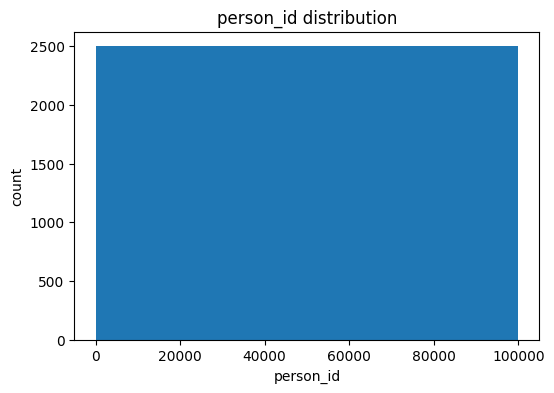

🔹 Distribution for: age


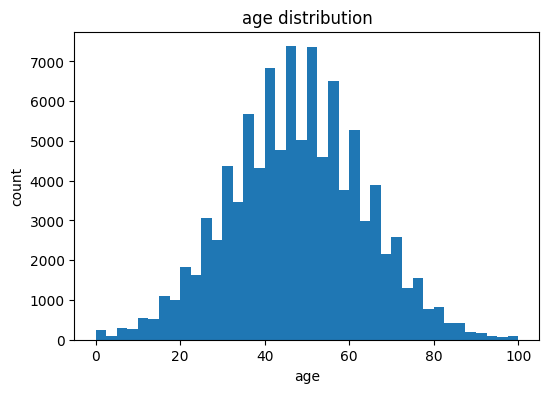

🔹 Distribution for: income


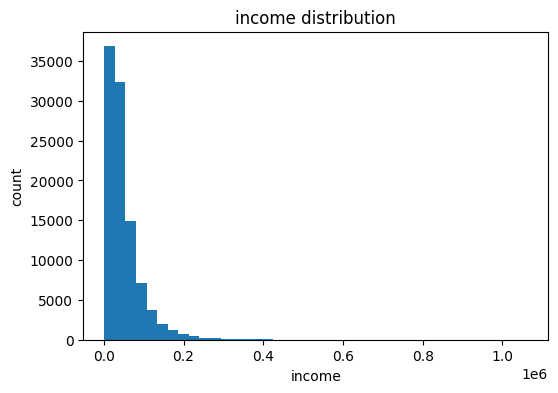

🔹 Distribution for: household_size


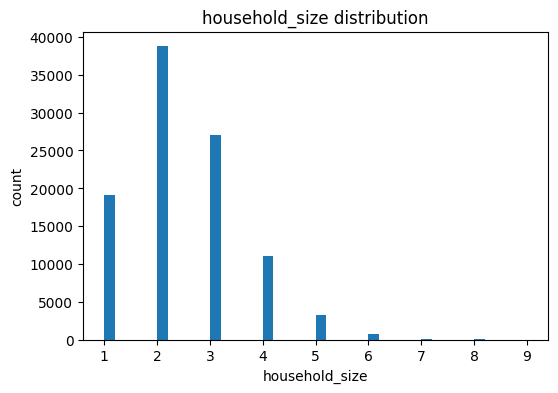

🔹 Distribution for: dependents


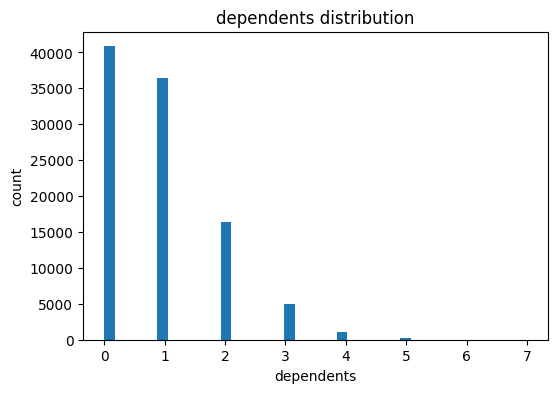

🔹 Distribution for: bmi


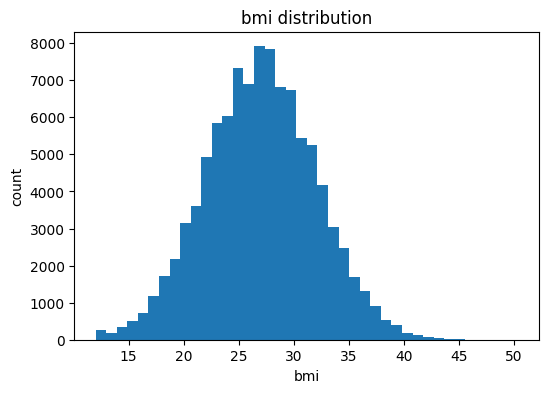

🔹 Distribution for: visits_last_year


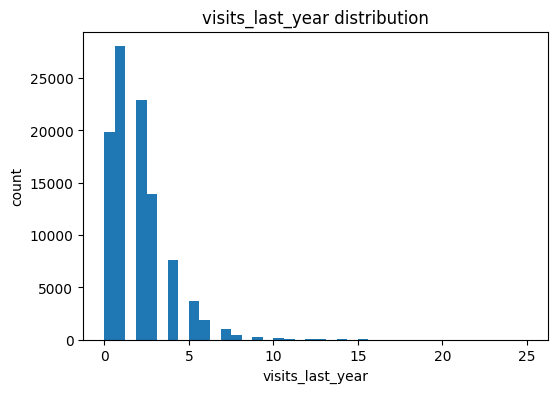

🔹 Distribution for: hospitalizations_last_3yrs


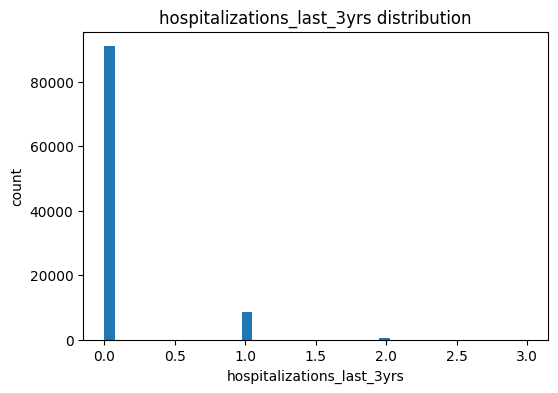

🔹 Distribution for: days_hospitalized_last_3yrs


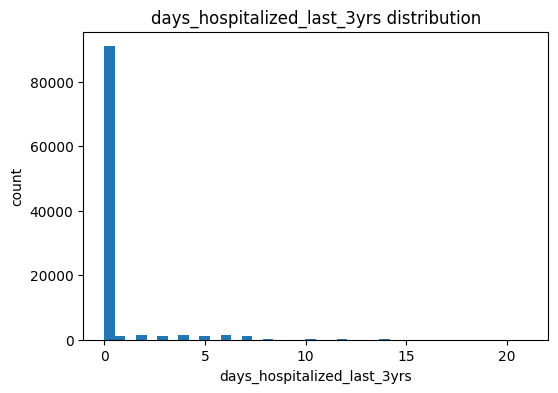

🔹 Distribution for: medication_count


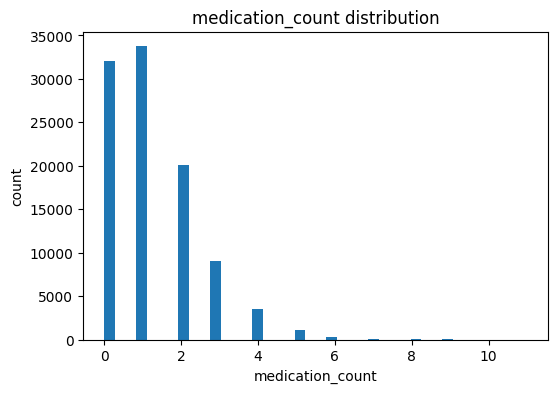

🔹 Distribution for: systolic_bp


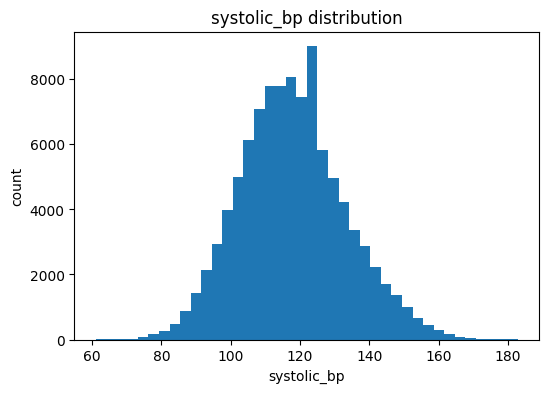

🔹 Distribution for: diastolic_bp


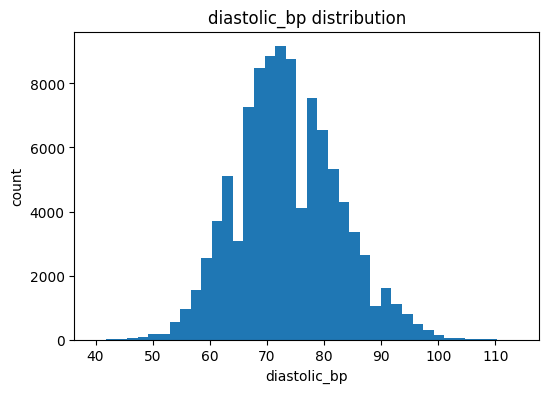

🔹 Distribution for: ldl


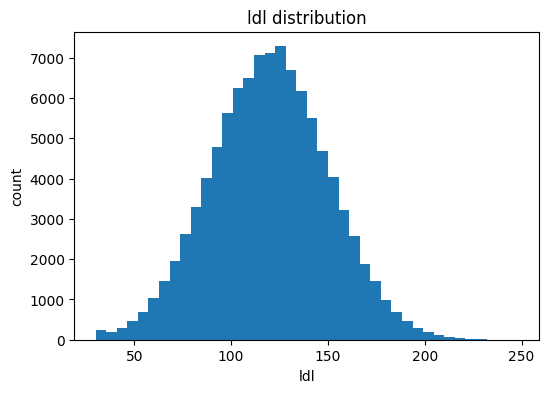

🔹 Distribution for: hba1c


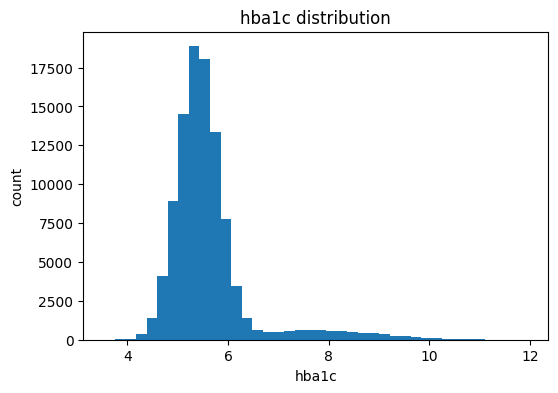

🔹 Distribution for: deductible


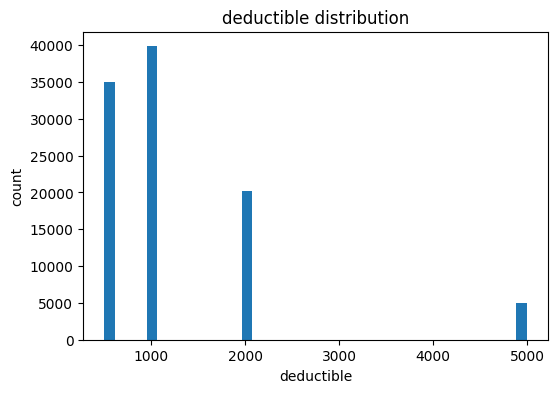

🔹 Distribution for: copay


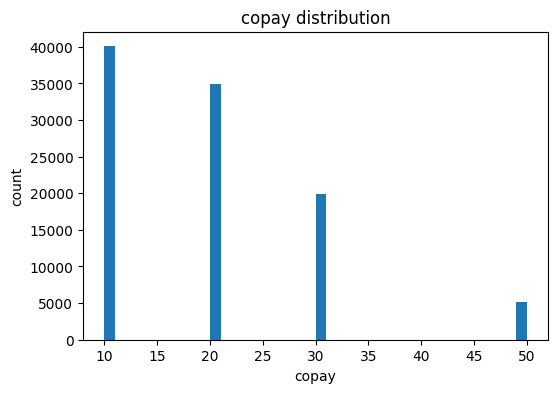

🔹 Distribution for: policy_term_years


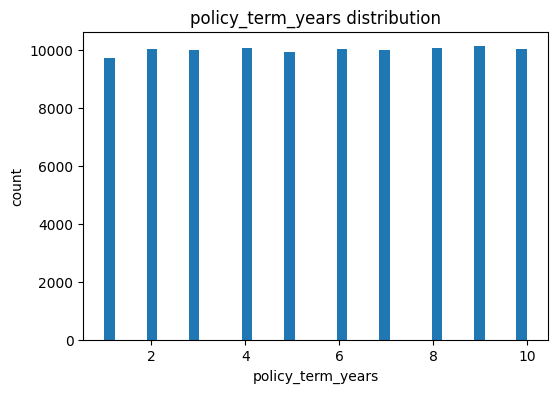

🔹 Distribution for: policy_changes_last_2yrs


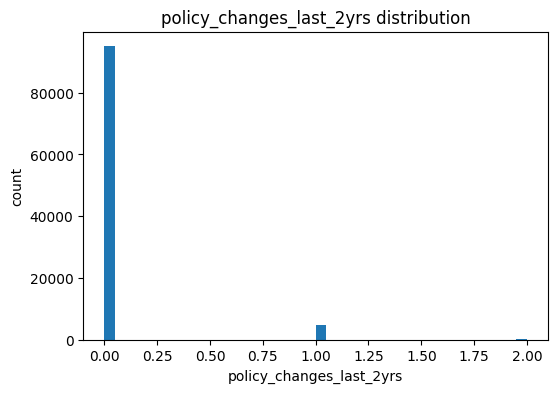

🔹 Distribution for: provider_quality


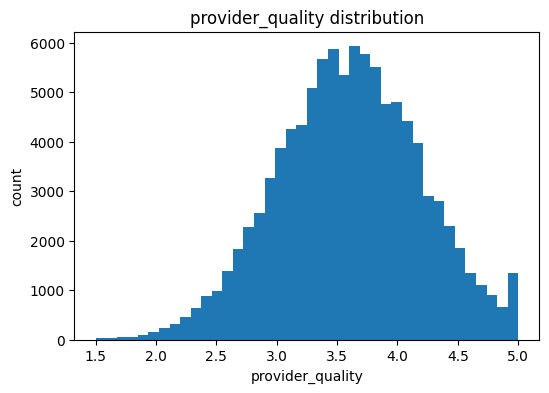

🔹 Distribution for: risk_score


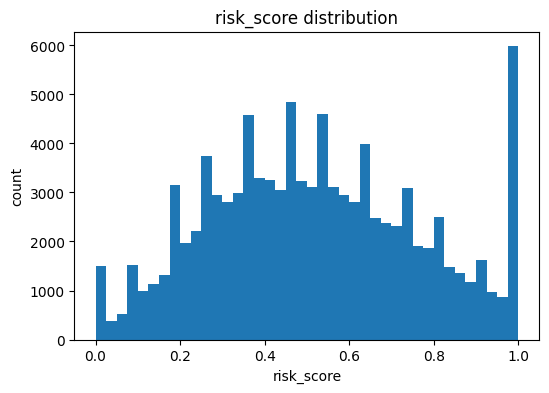

🔹 Distribution for: annual_medical_cost


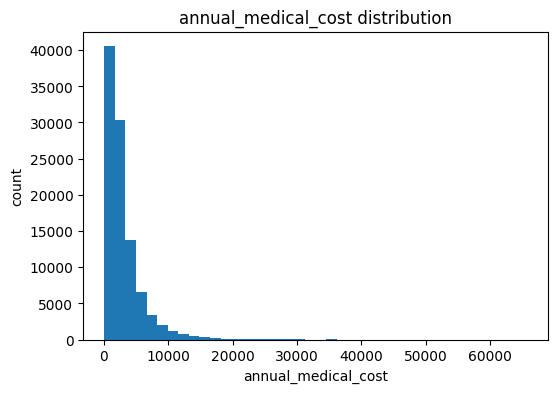

🔹 Distribution for: annual_premium


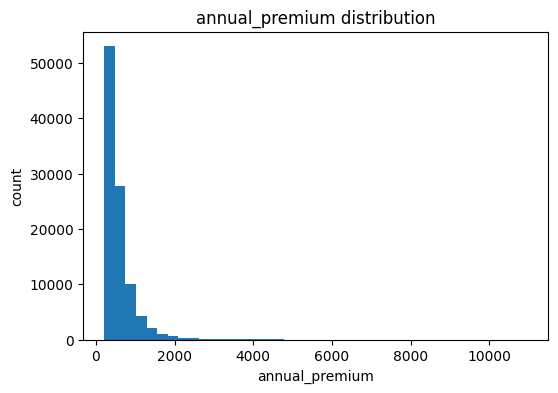

🔹 Distribution for: monthly_premium


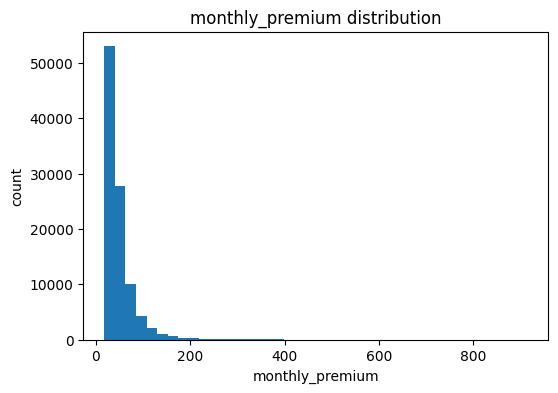

🔹 Distribution for: claims_count


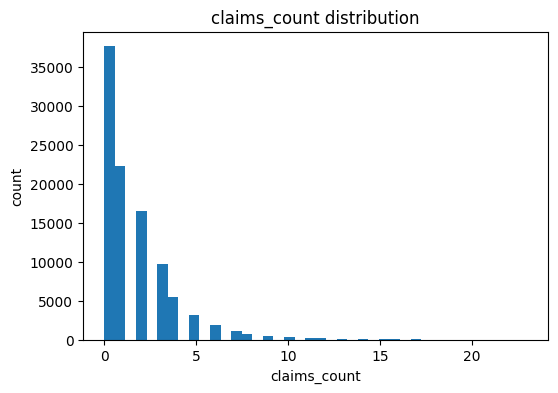

🔹 Distribution for: avg_claim_amount


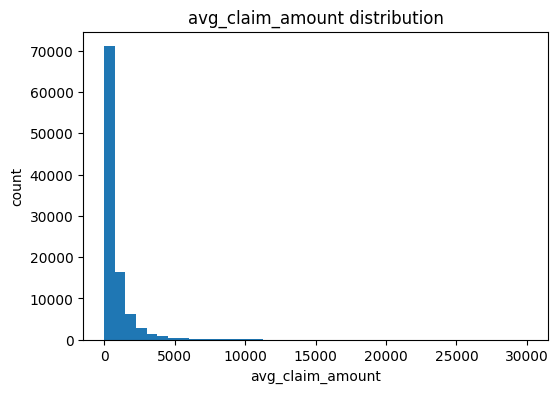

🔹 Distribution for: total_claims_paid


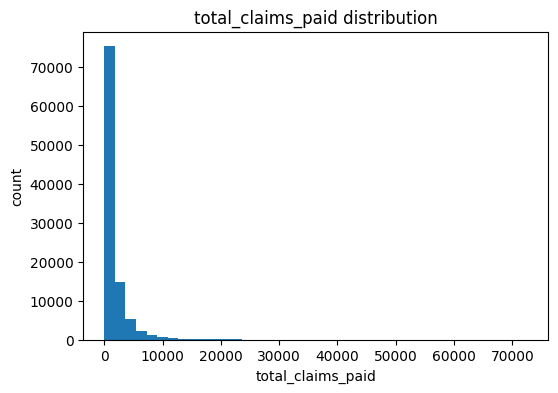

🔹 Distribution for: chronic_count


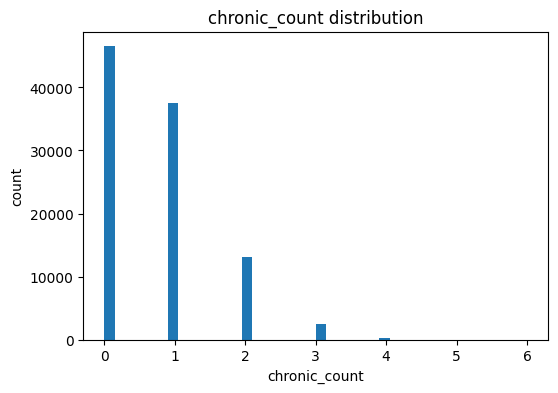

🔹 Distribution for: hypertension


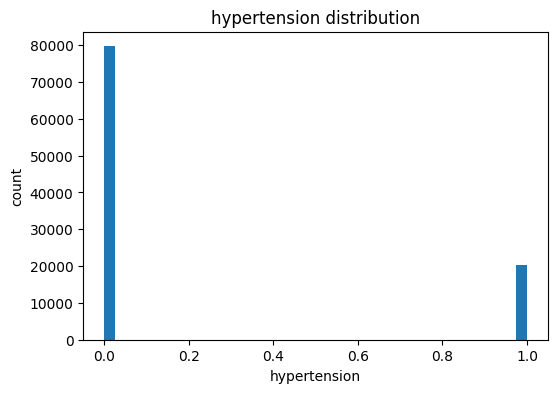

🔹 Distribution for: diabetes


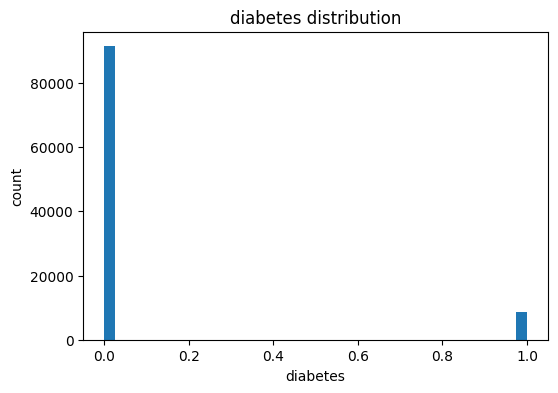

🔹 Distribution for: asthma


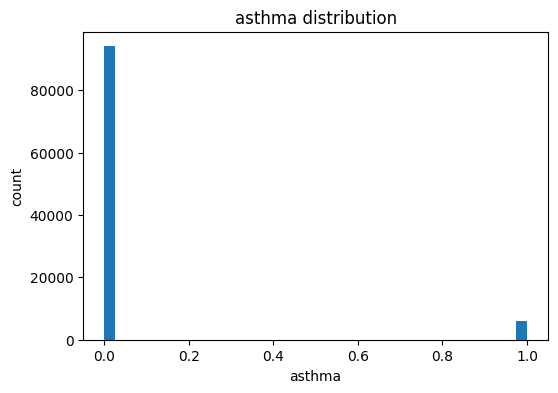

🔹 Distribution for: copd


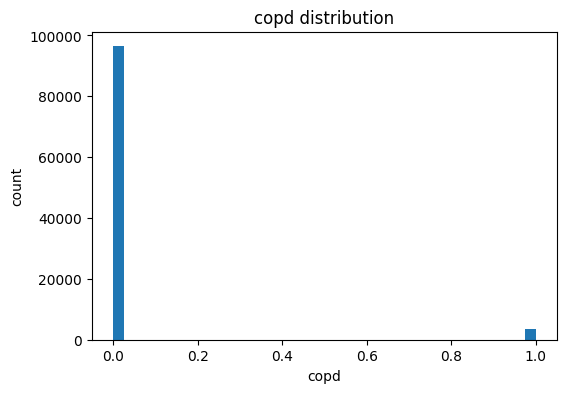

🔹 Distribution for: cardiovascular_disease


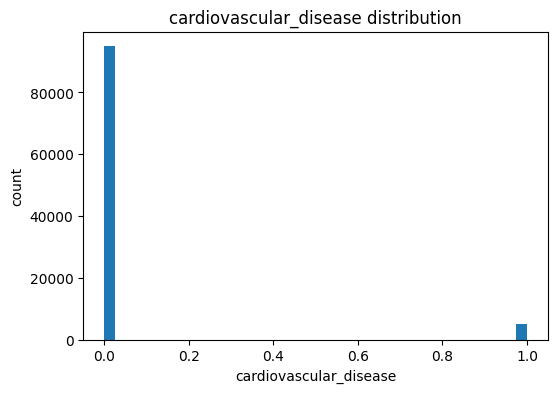

🔹 Distribution for: cancer_history


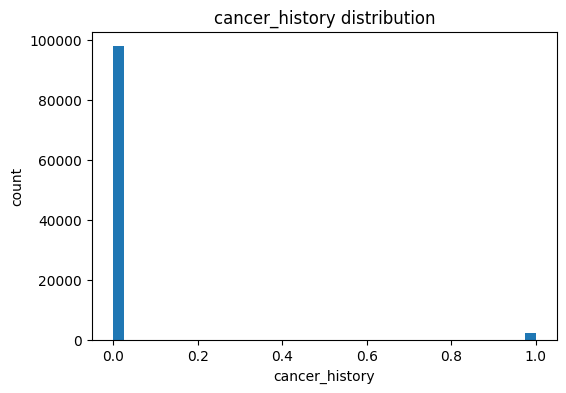

🔹 Distribution for: kidney_disease


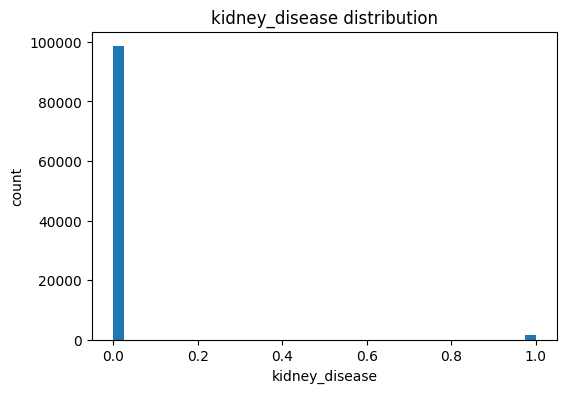

🔹 Distribution for: liver_disease


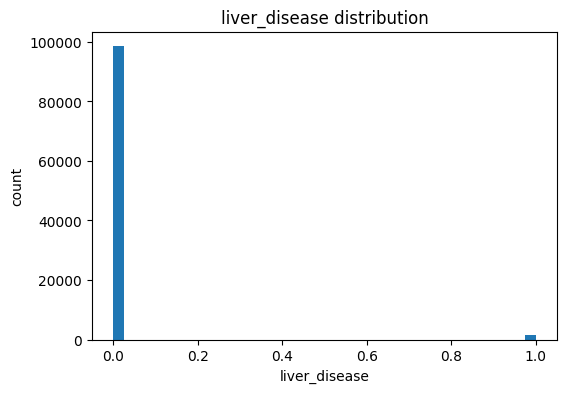

🔹 Distribution for: arthritis


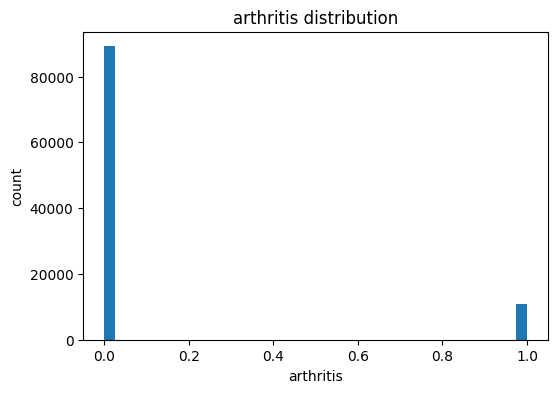

🔹 Distribution for: mental_health


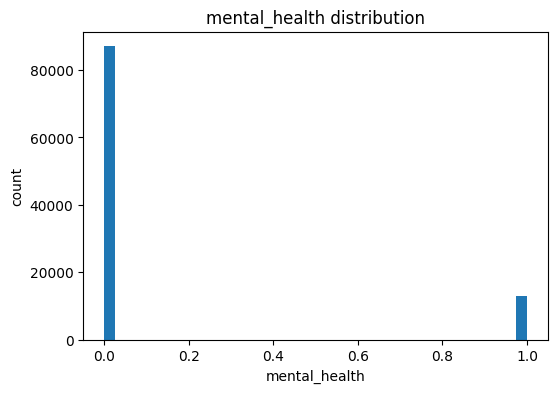

🔹 Distribution for: proc_imaging_count


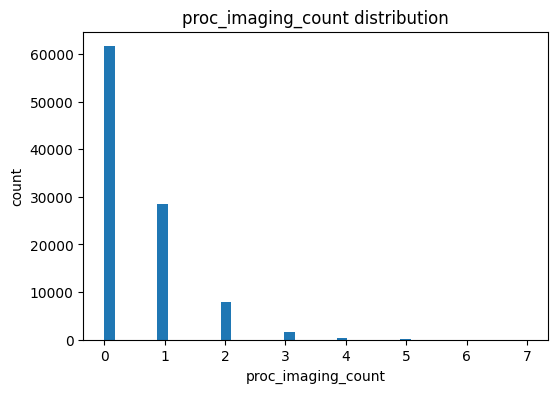

🔹 Distribution for: proc_surgery_count


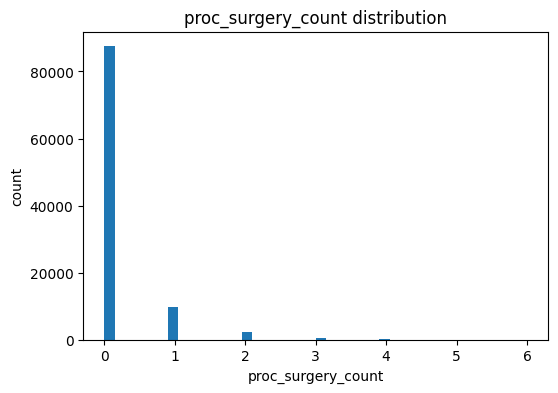

🔹 Distribution for: proc_physio_count


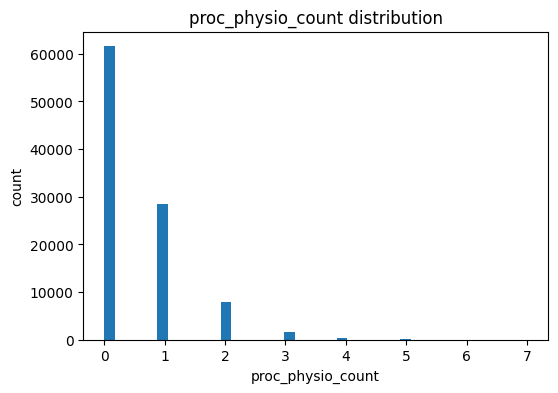

🔹 Distribution for: proc_consult_count


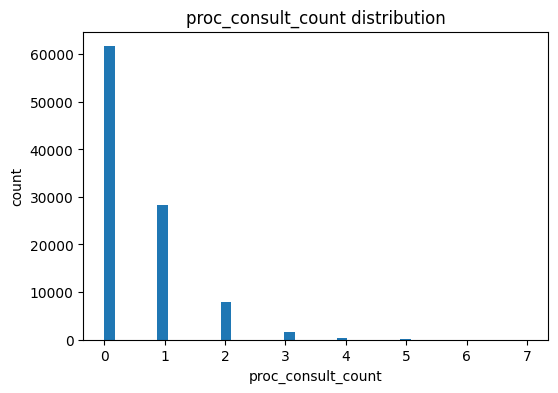

🔹 Distribution for: proc_lab_count


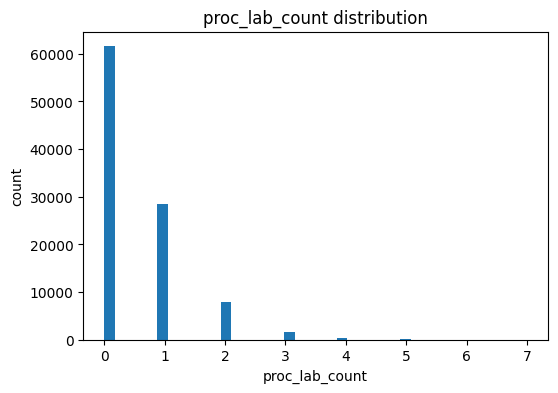

🔹 Distribution for: is_high_risk


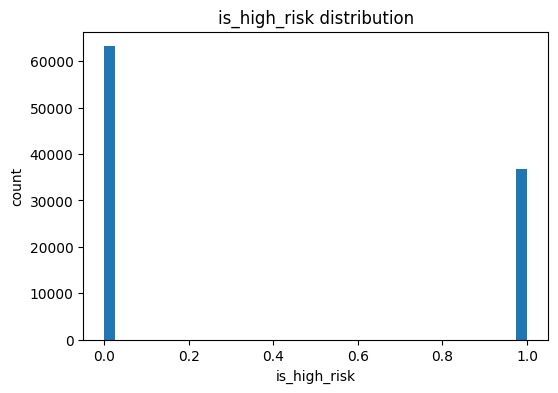

🔹 Distribution for: had_major_procedure


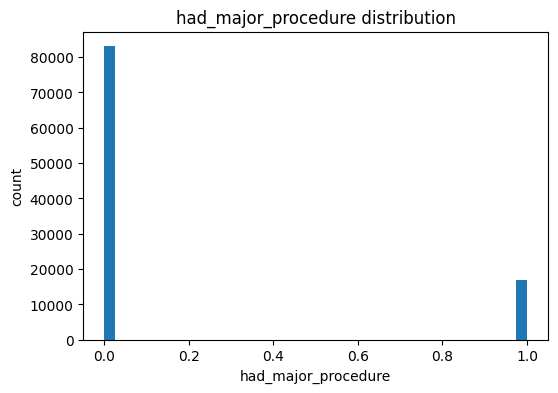


--- Potential Outlier Percentages ---


,outlier_%
hypertension,20.34
had_major_procedure,16.97
mental_health,13.01
proc_surgery_count,12.52
arthritis,10.83
days_hospitalized_last_3yrs,8.97
hospitalizations_last_3yrs,8.97
diabetes,8.59
hba1c,7.46
total_claims_paid,6.96


In [12]:
# ===============================================================
# Numerical Feature Distributions & Outlier Detection
# ===============================================================

# Identify numeric columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
print(f"Numeric columns ({len(num_cols)}): {num_cols}\n")

# Plot histograms for numeric variables
for col in num_cols:
    print(f"🔹 Distribution for: {col}")
    dist_plot(df[col], title=f"{col} distribution", log=False, bins=40)

# Optional: also inspect log-scale if values vary widely (e.g., cost variables)
possible_targets = ["annual_cost", "charges", "expenses", "medical_cost", "expenditure"]
for tgt in possible_targets:
    if tgt in df.columns:
        print(f"\n🔹 Log-scale distribution for: {tgt}")
        dist_plot(df[tgt], title=f"{tgt} (log1p scale)", log=True, bins=40)

# Quick numeric outlier check using IQR rule
outlier_summary = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_pct = ((df[col] < lower) | (df[col] > upper)).mean() * 100
    outlier_summary[col] = round(outlier_pct, 2)

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient="index", columns=["outlier_%"]).sort_values("outlier_%", ascending=False)
print("\n--- Potential Outlier Percentages ---")
display(outlier_df.head(15))


Categorical columns (10): ['sex', 'region', 'urban_rural', 'education', 'marital_status', 'employment_status', 'smoker', 'alcohol_freq', 'plan_type', 'network_tier']

🔹 Frequency distribution for: sex


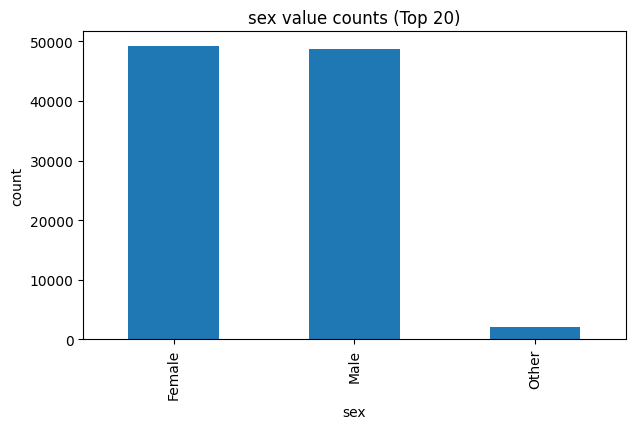

🔹 Frequency distribution for: region


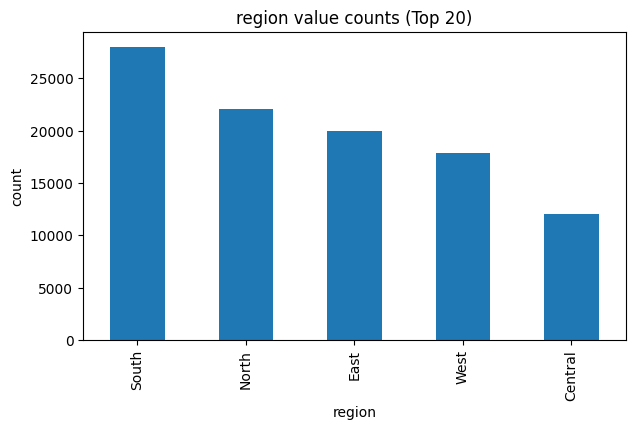

🔹 Frequency distribution for: urban_rural


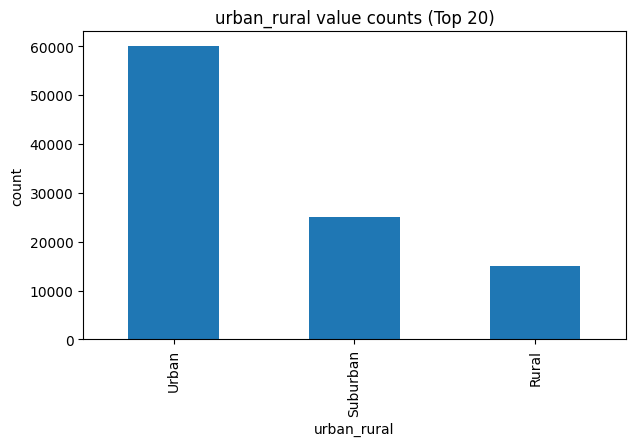

🔹 Frequency distribution for: education


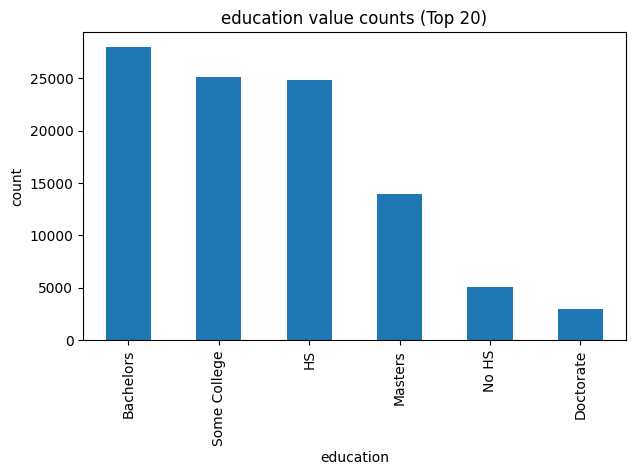

🔹 Frequency distribution for: marital_status


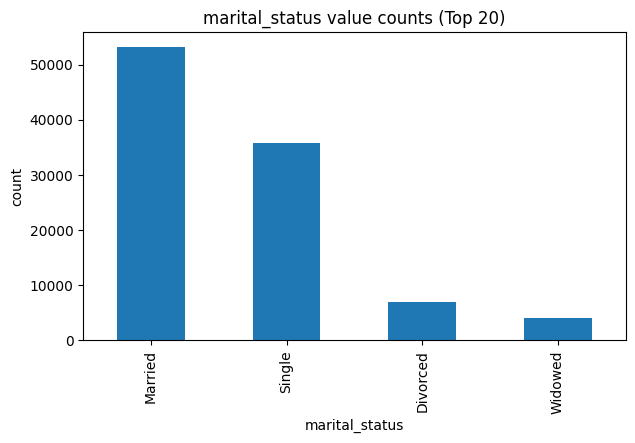

🔹 Frequency distribution for: employment_status


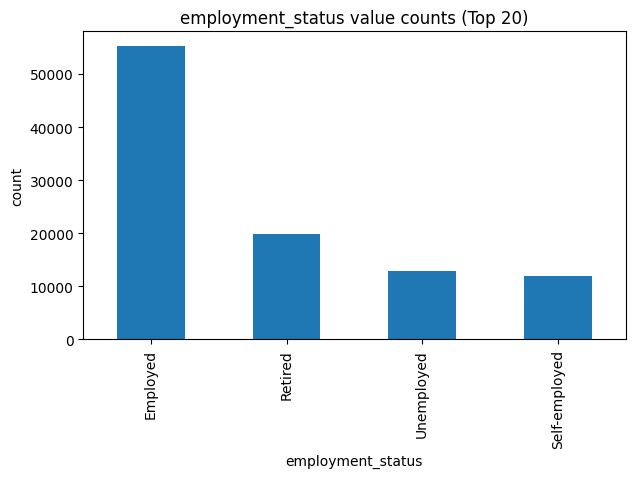

🔹 Frequency distribution for: smoker


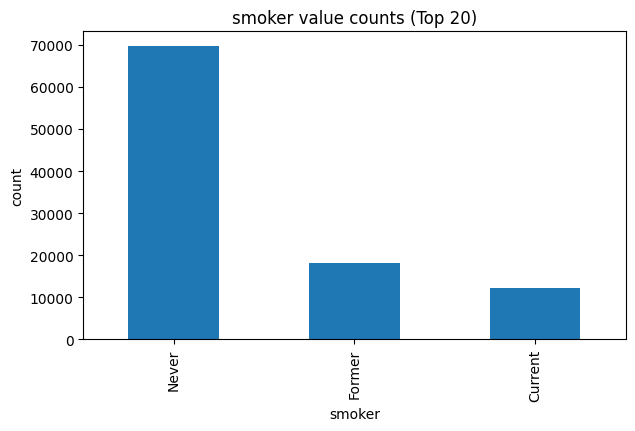

🔹 Frequency distribution for: alcohol_freq


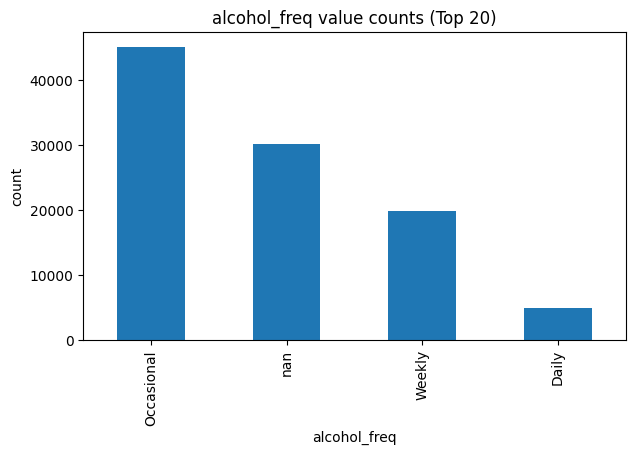

🔹 Frequency distribution for: plan_type


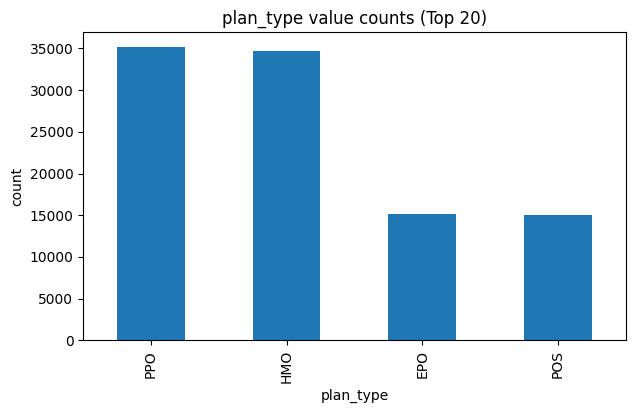

🔹 Frequency distribution for: network_tier


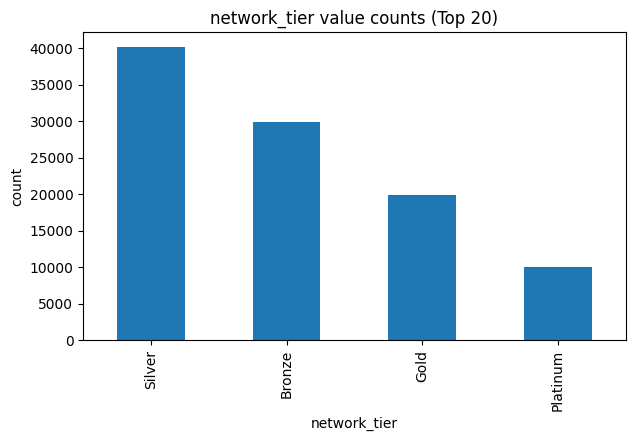

⚠️ No target variable identified yet. You can specify it manually later.


In [13]:
# ===============================================================
# Categorical Features Exploration & Target Relationships
# ===============================================================

# Identify categorical columns
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}\n")

# Frequency plots for each categorical variable
for col in cat_cols:
    print(f"🔹 Frequency distribution for: {col}")
    bar_topk_counts(df[col], title=f"{col} value counts (Top 20)")

# Try to identify potential target variable from earlier guess
target_candidates = ["annual_cost", "charges", "expenses", "medical_cost", "expenditure"]
target_col = None
for c in target_candidates:
    if c in df.columns:
        target_col = c
        print(f"✅ Target variable found: {target_col}")
        break

if target_col:
    # Relationship between categorical variables and target (mean cost per category)
    print(f"\n--- Average {target_col} by categorical features ---")
    for col in cat_cols:
        if df[col].nunique() <= 30:  # Only for manageable categories
            grouped = df.groupby(col)[target_col].mean().sort_values(ascending=False)
            display(grouped.head(10))
else:
    print("⚠️ No target variable identified yet. You can specify it manually later.")


✅ Correlation matrix computed.


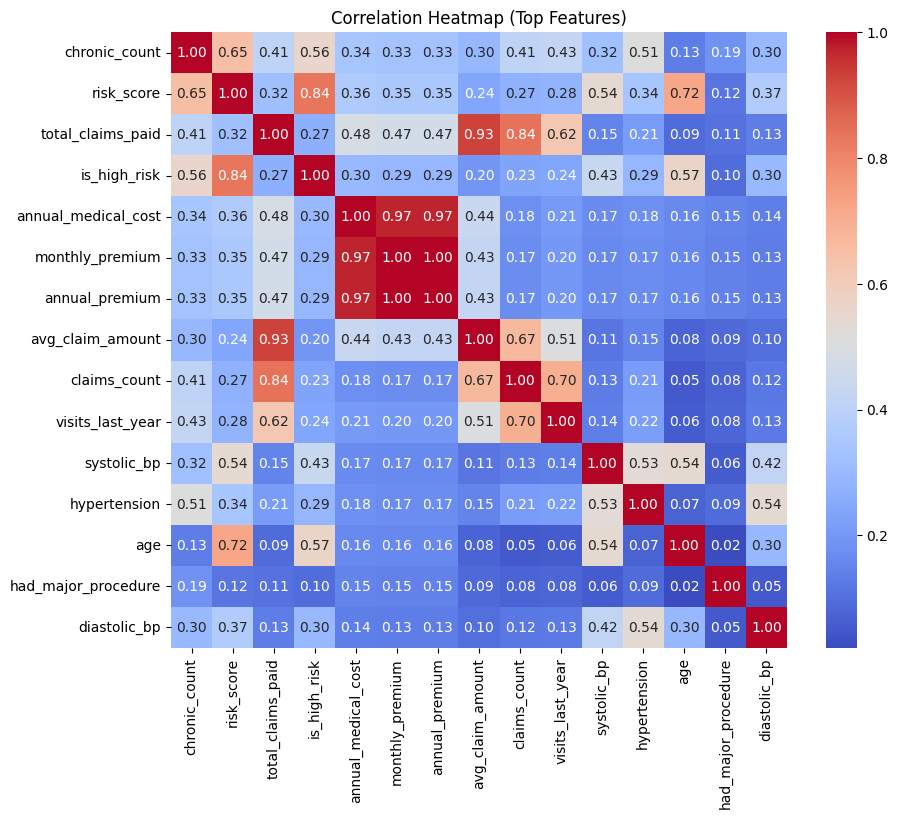

In [14]:
# ===============================================================
# Correlation Analysis (Numeric Relationships)
# ===============================================================

import seaborn as sns

# Identify numeric columns again (in case of previous filtering)
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Compute correlation matrix
corr_matrix = df[num_cols].corr(method="spearman")  # Spearman handles non-linear monotonic relations
print("✅ Correlation matrix computed.")

# Display top correlations with target (if identified)
if "target_col" in locals() and target_col:
    target_corr = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)
    print(f"\n🔹 Top correlations with {target_col}:")
    display(target_corr.head(10))
    print(f"\n🔹 Lowest correlations with {target_col}:")
    display(target_corr.tail(10))

# Plot correlation heatmap (top 15 numeric vars if too many)
top_corr_cols = (
    corr_matrix.abs().mean().sort_values(ascending=False).head(15).index
    if len(num_cols) > 15 else num_cols
)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix.loc[top_corr_cols, top_corr_cols],
            annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap (Top Features)")
plt.show()


In [15]:
# ===============================================================
# Bivariate Analysis: Predictor vs Target Relationships
# ===============================================================

# Ensure we have a target variable selected
if "target_col" not in locals() or target_col is None:
    # Try to find again if missed earlier
    target_candidates = ["annual_cost", "charges", "expenses", "medical_cost", "expenditure"]
    for c in target_candidates:
        if c in df.columns:
            target_col = c
            print(f"✅ Target variable found automatically: {target_col}")
            break

if target_col:
    # --- Numeric vs Target (scatterplots) ---
    print(f"\n📈 Scatterplots: numeric features vs {target_col}\n")
    numeric_features = [col for col in df.select_dtypes(include=["int64", "float64"]).columns if col != target_col]

    for col in numeric_features:
        fig = px.scatter(
            df,
            x=col,
            y=target_col,
            opacity=0.5,
            trendline="ols",
            title=f"{col} vs {target_col}",
        )
        fig.show()

    # --- Categorical vs Target (boxplots) ---
    print(f"\n📦 Boxplots: categorical features vs {target_col}\n")
    cat_features = df.select_dtypes(include=["object", "category"]).columns.tolist()

    for col in cat_features:
        if df[col].nunique() <= 10:  # only plot manageable categories
            fig = px.box(
                df,
                x=col,
                y=target_col,
                points="all",
                title=f"{col} vs {target_col}",
            )
            fig.show()
else:
    print("⚠️ Target variable not found. Please set target_col manually before running this cell.")


⚠️ Target variable not found. Please set target_col manually before running this cell.


In [16]:
# ===============================================================
# Final EDA Summary & Data Quality Checks
# ===============================================================

# ---- Duplicate checks ----
n_dupes = df.duplicated().sum()
print(f"🔍 Duplicate rows found: {n_dupes}")

# ---- Zero / negative checks for key numeric columns ----
print("\n⚙️ Checking zero/negative values (potential invalids):")
for col in df.select_dtypes(include=["int64", "float64"]).columns:
    negatives = (df[col] < 0).sum()
    zeros = (df[col] == 0).sum()
    if negatives > 0 or zeros > 0:
        print(f"{col:25s} | zeros: {zeros:6d} | negatives: {negatives:6d}")

# ---- Cardinality summary ----
cardinality = {c: df[c].nunique() for c in df.columns}
card_df = pd.DataFrame(cardinality.items(), columns=["column", "n_unique"]).sort_values("n_unique", ascending=False)
display(card_df.head(15))

# ---- Feature type summary ----
print("\n📋 Feature Type Summary:")
print(f"Numeric features: {len(df.select_dtypes(include=['int64','float64']).columns)}")
print(f"Categorical features: {len(df.select_dtypes(include=['object','category']).columns)}")

# ---- Target distribution summary ----
if "target_col" in locals() and target_col:
    print(f"\n🎯 Target variable summary: {target_col}")
    display(df[target_col].describe(percentiles=[.01, .05, .5, .95, .99]).to_frame().T)
    dist_plot(df[target_col], title=f"{target_col} (final distribution)", log=True)
else:
    print("⚠️ Target variable not identified yet.")

# ---- Save quick EDA summary to file ----
eda_summary = {
    "n_records": int(df.shape[0]),
    "n_features": int(df.shape[1]),
    "n_numeric": int(df.select_dtypes(include=['int64','float64']).shape[1]),
    "n_categorical": int(df.select_dtypes(include=['object','category']).shape[1]),
    "duplicates": int(n_dupes),
    "target_col": target_col if 'target_col' in locals() else None,
    "missing_cols": df.columns[df.isna().any()].tolist(),
    "high_cardinality_cols": card_df[card_df['n_unique'] > 50]['column'].tolist(),
}

with open(REPORT_DIR / "eda_summary.json", "w") as f:
    json.dump(eda_summary, f, indent=2)

print("\n✅ EDA summary report saved to: reports/eda_summary.json")
print(json.dumps(eda_summary, indent=2))


🔍 Duplicate rows found: 0

⚙️ Checking zero/negative values (potential invalids):
age                       | zeros:    165 | negatives:      0
dependents                | zeros:  40836 | negatives:      0
visits_last_year          | zeros:  19865 | negatives:      0
hospitalizations_last_3yrs | zeros:  91031 | negatives:      0
days_hospitalized_last_3yrs | zeros:  91031 | negatives:      0
medication_count          | zeros:  32043 | negatives:      0
policy_changes_last_2yrs  | zeros:  95047 | negatives:      0
risk_score                | zeros:   1131 | negatives:      0
claims_count              | zeros:  37663 | negatives:      0
avg_claim_amount          | zeros:  37663 | negatives:      0
total_claims_paid         | zeros:  37663 | negatives:      0
chronic_count             | zeros:  46532 | negatives:      0
hypertension              | zeros:  79655 | negatives:      0
diabetes                  | zeros:  91407 | negatives:      0
asthma                    | zeros:  94113 | neg

,column,n_unique
0,person_id,100000
30,annual_medical_cost,91299
35,total_claims_paid,56650
31,annual_premium,55538
34,avg_claim_amount,53071
32,monthly_premium,12339
5,income,2987
20,ldl,1881
21,hba1c,732
28,provider_quality,350



📋 Feature Type Summary:
Numeric features: 44
Categorical features: 10
⚠️ Target variable not identified yet.

✅ EDA summary report saved to: reports/eda_summary.json
{
  "n_records": 100000,
  "n_features": 54,
  "n_numeric": 44,
  "n_categorical": 10,
  "duplicates": 0,
  "target_col": null,
  "missing_cols": [
    "alcohol_freq"
  ],
  "high_cardinality_cols": [
    "person_id",
    "annual_medical_cost",
    "total_claims_paid",
    "annual_premium",
    "avg_claim_amount",
    "monthly_premium",
    "income",
    "ldl",
    "hba1c",
    "provider_quality",
    "bmi",
    "systolic_bp",
    "age",
    "risk_score",
    "diastolic_bp"
  ]
}


In [17]:
# ===============================================================
# PHASE 2 - DATA PREPARATION & FEATURE ENGINEERING
# ===============================================================

# Manually set the correct target column
target_col = "annual_medical_cost"   # confirmed target variable

print(f"🎯 Target variable set to: {target_col}")

# Identify feature columns (exclude target)
feature_cols = [c for c in df.columns if c != target_col]

# Separate numeric and categorical features
num_features = df[feature_cols].select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = df[feature_cols].select_dtypes(include=["object", "category"]).columns.tolist()

print(f"✅ Feature identification complete:")
print(f"   • Total features: {len(feature_cols)}")
print(f"   • Numeric features: {len(num_features)}")
print(f"   • Categorical features: {len(cat_features)}")
print(f"\nNumeric columns: {num_features[:8]} ...")
print(f"Categorical columns: {cat_features[:8]} ...")


🎯 Target variable set to: annual_medical_cost
✅ Feature identification complete:
   • Total features: 53
   • Numeric features: 43
   • Categorical features: 10

Numeric columns: ['person_id', 'age', 'income', 'household_size', 'dependents', 'bmi', 'visits_last_year', 'hospitalizations_last_3yrs'] ...
Categorical columns: ['sex', 'region', 'urban_rural', 'education', 'marital_status', 'employment_status', 'smoker', 'alcohol_freq'] ...


In [18]:
# ===============================================================
# Handle Missing Values & Data Type Adjustments
# ===============================================================

print("🔍 Checking missing values before cleaning...")
missing = df[feature_cols].isna().sum()
display(missing[missing > 0])

# ---- Step 1: Handle missing numeric values ----
# Replace missing numeric values with median
for col in num_features:
    if df[col].isna().sum() > 0:
        median_value = df[col].median()
        df[col].fillna(median_value, inplace=True)
        print(f"Filled missing numeric values in '{col}' with median ({median_value:.2f})")

# ---- Step 2: Handle missing categorical values ----
# Replace missing categorical values with "Unknown"
for col in cat_features:
    if df[col].isna().sum() > 0:
        df[col].fillna("Unknown", inplace=True)
        print(f"Filled missing categorical values in '{col}' with 'Unknown'")

# ---- Step 3: Convert binary flags to category (if 0/1 columns) ----
binary_candidates = [col for col in num_features if set(df[col].unique()) <= {0, 1}]
if binary_candidates:
    for col in binary_candidates:
        df[col] = df[col].astype("category")
        cat_features.append(col)
        num_features.remove(col)
    print(f"Converted binary columns to categorical: {binary_candidates}")

# ---- Step 4: Verify cleaning ----
print("\n✅ Missing value check after cleaning:")
display(df[feature_cols].isna().sum().sum())
print("✅ Data cleaning complete.")


🔍 Checking missing values before cleaning...


,0
alcohol_freq,30083


Filled missing categorical values in 'alcohol_freq' with 'Unknown'
Converted binary columns to categorical: ['hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'is_high_risk', 'had_major_procedure']

✅ Missing value check after cleaning:


np.int64(0)

✅ Data cleaning complete.


In [19]:
# ===============================================================
# Feature Engineering: Encoding & Scaling Pipelines
# ===============================================================

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- Numeric pipeline ---
numeric_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# --- Categorical pipeline ---
categorical_pipeline = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# --- Combined preprocessor ---
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, num_features),
        ("cat", categorical_pipeline, cat_features)
    ],
    remainder="drop"  # drop unused columns
)

print("✅ Preprocessing pipelines created successfully.")
print(f"Numeric features: {len(num_features)}")
print(f"Categorical features: {len(cat_features)}")


✅ Preprocessing pipelines created successfully.
Numeric features: 31
Categorical features: 22


In [20]:
# ===============================================================
# Train / Validation / Test Split Creation
# ===============================================================

from sklearn.model_selection import train_test_split

# Define feature matrix (X) and target vector (y)
X = df[feature_cols]
y = df[target_col]

# For regression, create cost bins to help stratify roughly
y_bins = pd.qcut(y.rank(method="first"), q=10, labels=False, duplicates="drop")

# Split into train + test first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y_bins
)

# Now split train further into validation
y_train_bins = pd.qcut(y_train.rank(method="first"), q=10, labels=False, duplicates="drop")

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train_bins
)

# Display results
print("✅ Data split completed successfully.")
print(f"Train set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")

# Save indices (for reproducibility)
np.save(PROC_DIR / "train_idx.npy", X_train.index)
np.save(PROC_DIR / "val_idx.npy", X_val.index)
np.save(PROC_DIR / "test_idx.npy", X_test.index)


✅ Data split completed successfully.
Train set: (64000, 53)
Validation set: (16000, 53)
Test set: (20000, 53)


In [21]:
# ===============================================================
# Apply Preprocessing Pipeline to Train/Val/Test Sets
# ===============================================================

# Fit the preprocessor only on training data
print("🏗️ Fitting preprocessing pipeline on training data...")
X_train_prep = preprocessor.fit_transform(X_train)

# Apply the same transformations to validation and test data
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

print("✅ Transformation complete.")
print(f"Transformed training set shape: {X_train_prep.shape}")
print(f"Transformed validation set shape: {X_val_prep.shape}")
print(f"Transformed test set shape: {X_test_prep.shape}")

# Get feature names after transformation (for interpretability)
encoded_feature_names = preprocessor.get_feature_names_out()
X_train_prep = pd.DataFrame(X_train_prep, columns=encoded_feature_names, index=X_train.index)
X_val_prep = pd.DataFrame(X_val_prep, columns=encoded_feature_names, index=X_val.index)
X_test_prep = pd.DataFrame(X_test_prep, columns=encoded_feature_names, index=X_test.index)

# Quick check: ensure no missing or infinite values remain
assert not np.isnan(X_train_prep.values).any(), "NaNs found in training data!"
assert not np.isinf(X_train_prep.values).any(), "Infs found in training data!"

print("✅ Processed datasets are clean and ready for modeling.")


🏗️ Fitting preprocessing pipeline on training data...
✅ Transformation complete.
Transformed training set shape: (64000, 95)
Transformed validation set shape: (16000, 95)
Transformed test set shape: (20000, 95)
✅ Processed datasets are clean and ready for modeling.


In [22]:
# ===============================================================
# Domain-Driven Feature Engineering (Fixed)
# ===============================================================

df_fe = df.copy()

# --- 1. Health-related composite features ---
df_fe["bp_ratio"] = df_fe["systolic_bp"] / df_fe["diastolic_bp"]
df_fe["bmi_risk"] = pd.cut(
    df_fe["bmi"],
    bins=[0, 18.5, 25, 30, 35, 100],
    labels=["Underweight", "Normal", "Overweight", "Obese", "Extremely Obese"]
)

# --- 2. Cost efficiency metrics ---
df_fe["claim_efficiency"] = np.where(
    df_fe["claims_count"] > 0,
    df_fe["total_claims_paid"] / df_fe["claims_count"],
    0
)

df_fe["premium_to_cost_ratio"] = (
    df_fe["annual_premium"] / (df_fe["annual_medical_cost"] + 1)
)

# --- 3. Utilization intensity ---
df_fe["proc_total"] = (
    df_fe["proc_imaging_count"] +
    df_fe["proc_surgery_count"] +
    df_fe["proc_physio_count"] +
    df_fe["proc_consult_count"] +
    df_fe["proc_lab_count"]
)

df_fe["visit_intensity"] = (
    df_fe["visits_last_year"] + df_fe["hospitalizations_last_3yrs"]
)

# --- 4. Chronic condition grouping (fix: convert categorical to numeric) ---
chronic_conditions = [
    "hypertension", "diabetes", "asthma", "copd", "cardiovascular_disease",
    "cancer_history", "kidney_disease", "liver_disease", "arthritis", "mental_health"
]

# Convert any categorical or boolean columns to numeric (0/1)
for col in chronic_conditions:
    df_fe[col] = pd.to_numeric(df_fe[col], errors="coerce").fillna(0).astype(int)

# Now safely sum across them
df_fe["chronic_total"] = df_fe[chronic_conditions].sum(axis=1)
df_fe["has_multiple_chronic"] = (df_fe["chronic_total"] >= 2).astype(int)

# --- 5. Interaction features ---
df_fe["age_x_bmi"] = df_fe["age"] * df_fe["bmi"]
df_fe["income_x_risk"] = df_fe["income"] * df_fe["risk_score"]

# --- 6. Update numeric & categorical lists ---
new_numeric = df_fe.select_dtypes(include=["int64", "float64"]).columns.tolist()
new_categorical = df_fe.select_dtypes(include=["object", "category"]).columns.tolist()

print("✅ Feature engineering successful!")
print(f"Numeric columns: {len(new_numeric)} | Categorical columns: {len(new_categorical)}")

# Display some new engineered columns
df_fe[[
    "bp_ratio", "bmi_risk", "claim_efficiency", "premium_to_cost_ratio",
    "proc_total", "chronic_total", "has_multiple_chronic", "age_x_bmi", "income_x_risk"
]].head()


✅ Feature engineering successful!
Numeric columns: 51 | Categorical columns: 13


,bp_ratio,bmi_risk,claim_efficiency,premium_to_cost_ratio,proc_total,chronic_total,has_multiple_chronic,age_x_bmi,income_x_risk
0,1.592105,Overweight,4672.59,0.126249,4,1,0,1424.8,12970.78
1,1.658228,Overweight,297.27,0.272464,2,2,1,2101.4,12800.00
2,1.904762,Obese,0.00,0.200733,4,3,1,2142.0,40700.00
3,1.529412,Obese,0.00,0.159927,2,1,0,474.0,4456.92
4,1.638554,Obese,1002.24,0.294365,4,2,1,1616.5,77781.76


In [23]:
# ===============================================================
# Update Preprocessing Pipeline with Engineered Features
# ===============================================================

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify updated numeric and categorical columns
num_features_fe = df_fe.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features_fe = df_fe.select_dtypes(include=["object", "category"]).columns.tolist()

# Exclude the target from feature lists
num_features_fe = [c for c in num_features_fe if c != target_col]
cat_features_fe = [c for c in cat_features_fe if c != target_col]

print(f"Updated numeric features: {len(num_features_fe)}")
print(f"Updated categorical features: {len(cat_features_fe)}")

# --- Updated pipelines ---
numeric_pipeline_fe = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_pipeline_fe = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# --- Combine numeric + categorical ---
preprocessor_fe = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline_fe, num_features_fe),
        ("cat", categorical_pipeline_fe, cat_features_fe)
    ],
    remainder="drop"
)

# --- Train/val/test split again using engineered dataset ---
X = df_fe.drop(columns=[target_col])
y = df_fe[target_col]

y_bins = pd.qcut(y.rank(method="first"), q=10, labels=False, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y_bins
)

y_train_bins = pd.qcut(y_train.rank(method="first"), q=10, labels=False, duplicates="drop")
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train_bins
)

# --- Apply preprocessing ---
print("🏗️ Applying preprocessing pipeline to engineered data...")
X_train_prep = preprocessor_fe.fit_transform(X_train)
X_val_prep = preprocessor_fe.transform(X_val)
X_test_prep = preprocessor_fe.transform(X_test)

# Convert back to DataFrames
encoded_feature_names_fe = preprocessor_fe.get_feature_names_out()
X_train_prep = pd.DataFrame(X_train_prep, columns=encoded_feature_names_fe, index=X_train.index)
X_val_prep = pd.DataFrame(X_val_prep, columns=encoded_feature_names_fe, index=X_val.index)
X_test_prep = pd.DataFrame(X_test_prep, columns=encoded_feature_names_fe, index=X_test.index)

print("✅ Engineered data preprocessing complete.")
print(f"Train: {X_train_prep.shape}, Val: {X_val_prep.shape}, Test: {X_test_prep.shape}")


Updated numeric features: 50
Updated categorical features: 13
🏗️ Applying preprocessing pipeline to engineered data...
✅ Engineered data preprocessing complete.
Train: (64000, 99), Val: (16000, 99), Test: (20000, 99)


In [24]:
# ===============================================================
# Save Processed Datasets & Metadata
# ===============================================================

# Save the processed train/validation/test datasets
X_train_prep.to_parquet(PROC_DIR / "X_train_processed.parquet")
X_val_prep.to_parquet(PROC_DIR / "X_val_processed.parquet")
X_test_prep.to_parquet(PROC_DIR / "X_test_processed.parquet")

y_train.to_csv(PROC_DIR / "y_train.csv", index=False)
y_val.to_csv(PROC_DIR / "y_val.csv", index=False)
y_test.to_csv(PROC_DIR / "y_test.csv", index=False)

# Save metadata about the preprocessing
metadata = {
    "target_col": target_col,
    "numeric_features": num_features_fe,
    "categorical_features": cat_features_fe,
    "engineered_features": [
        "bp_ratio", "bmi_risk", "claim_efficiency", "premium_to_cost_ratio",
        "proc_total", "visit_intensity", "chronic_total", "has_multiple_chronic",
        "age_x_bmi", "income_x_risk"
    ],
    "train_shape": X_train_prep.shape,
    "val_shape": X_val_prep.shape,
    "test_shape": X_test_prep.shape
}

with open(PROC_DIR / "feature_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("✅ Processed datasets and metadata saved successfully.")
print(json.dumps(metadata, indent=2))


✅ Processed datasets and metadata saved successfully.
{
  "target_col": "annual_medical_cost",
  "numeric_features": [
    "person_id",
    "age",
    "income",
    "household_size",
    "dependents",
    "bmi",
    "visits_last_year",
    "hospitalizations_last_3yrs",
    "days_hospitalized_last_3yrs",
    "medication_count",
    "systolic_bp",
    "diastolic_bp",
    "ldl",
    "hba1c",
    "deductible",
    "copay",
    "policy_term_years",
    "policy_changes_last_2yrs",
    "provider_quality",
    "risk_score",
    "annual_premium",
    "monthly_premium",
    "claims_count",
    "avg_claim_amount",
    "total_claims_paid",
    "chronic_count",
    "hypertension",
    "diabetes",
    "asthma",
    "copd",
    "cardiovascular_disease",
    "cancer_history",
    "kidney_disease",
    "liver_disease",
    "arthritis",
    "mental_health",
    "proc_imaging_count",
    "proc_surgery_count",
    "proc_physio_count",
    "proc_consult_count",
    "proc_lab_count",
    "bp_ratio",
    "cl

In [25]:
# ===============================================================
# PHASE 3 - MODEL DEVELOPMENT & EVALUATION
# ===============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# --- Load preprocessed data ---
X_train_prep = pd.read_parquet(PROC_DIR / "X_train_processed.parquet")
X_val_prep = pd.read_parquet(PROC_DIR / "X_val_processed.parquet")
X_test_prep = pd.read_parquet(PROC_DIR / "X_test_processed.parquet")

y_train = pd.read_csv(PROC_DIR / "y_train.csv").squeeze()
y_val = pd.read_csv(PROC_DIR / "y_val.csv").squeeze()
y_test = pd.read_csv(PROC_DIR / "y_test.csv").squeeze()

print("✅ Processed data loaded successfully.")
print(f"Train: {X_train_prep.shape}, Validation: {X_val_prep.shape}, Test: {X_test_prep.shape}")

# --- Baseline: Simple Linear Regression ---
linreg = LinearRegression()
linreg.fit(X_train_prep, y_train)

# Validation predictions
y_val_pred = linreg.predict(X_val_prep)

# Evaluation metrics
mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)

print("\n📊 Baseline Linear Regression Results (Validation Set):")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:,.3f}")


✅ Processed data loaded successfully.
Train: (64000, 99), Validation: (16000, 99), Test: (20000, 99)

📊 Baseline Linear Regression Results (Validation Set):
MAE  : 308.35
RMSE : 578.69
R²   : 0.964


In [26]:
# ===============================================================
# Regularized Linear Models: Ridge, Lasso, ElasticNet
# ===============================================================

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV

def evaluate_model(model, X, y, name="Model"):
    """Helper function to print evaluation metrics."""
    preds = model.predict(X)
    mae = mean_absolute_error(y, preds)
    rmse = np.sqrt(mean_squared_error(y, preds))
    r2 = r2_score(y, preds)
    print(f"\n📈 {name} Performance:")
    print(f"MAE  : {mae:,.2f}")
    print(f"RMSE : {rmse:,.2f}")
    print(f"R²   : {r2:,.3f}")
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

# --- Ridge Regression ---
ridge_params = {"alpha": [0.1, 1, 10, 50, 100]}
ridge = GridSearchCV(Ridge(random_state=SEED), ridge_params, cv=5, scoring="neg_root_mean_squared_error")
ridge.fit(X_train_prep, y_train)
ridge_best = ridge.best_estimator_

print(f"✅ Best Ridge alpha: {ridge.best_params_}")
ridge_results = evaluate_model(ridge_best, X_val_prep, y_val, "Ridge Regression")

# --- Lasso Regression ---
lasso_params = {"alpha": [0.0001, 0.001, 0.01, 0.1, 1]}
lasso = GridSearchCV(Lasso(random_state=SEED, max_iter=5000), lasso_params, cv=5, scoring="neg_root_mean_squared_error")
lasso.fit(X_train_prep, y_train)
lasso_best = lasso.best_estimator_

print(f"✅ Best Lasso alpha: {lasso.best_params_}")
lasso_results = evaluate_model(lasso_best, X_val_prep, y_val, "Lasso Regression")

# --- ElasticNet Regression ---
enet_params = {
    "alpha": [0.001, 0.01, 0.1, 1],
    "l1_ratio": [0.2, 0.5, 0.8]
}
enet = GridSearchCV(ElasticNet(random_state=SEED, max_iter=5000), enet_params, cv=5, scoring="neg_root_mean_squared_error")
enet.fit(X_train_prep, y_train)
enet_best = enet.best_estimator_

print(f"✅ Best ElasticNet params: {enet.best_params_}")
enet_results = evaluate_model(enet_best, X_val_prep, y_val, "ElasticNet Regression")

# --- Summary comparison ---
results_df = pd.DataFrame([
    {"Model": "Linear Regression", "MAE": mae, "RMSE": rmse, "R2": r2},
    {"Model": "Ridge", **ridge_results},
    {"Model": "Lasso", **lasso_results},
    {"Model": "ElasticNet", **enet_results},
])

display(results_df.sort_values("RMSE"))


✅ Best Ridge alpha: {'alpha': 10}

📈 Ridge Regression Performance:
MAE  : 308.28
RMSE : 578.64
R²   : 0.964
✅ Best Lasso alpha: {'alpha': 1}

📈 Lasso Regression Performance:
MAE  : 306.80
RMSE : 578.19
R²   : 0.964
✅ Best ElasticNet params: {'alpha': 0.001, 'l1_ratio': 0.5}

📈 ElasticNet Regression Performance:
MAE  : 308.14
RMSE : 578.57
R²   : 0.964


,Model,MAE,RMSE,R2
2,Lasso,306.800702,578.193799,0.964177
3,ElasticNet,308.135268,578.566233,0.964131
1,Ridge,308.282214,578.642118,0.964121
0,Linear Regression,308.350979,578.694989,0.964115


In [27]:
# ===============================================================
# Tree-Based Ensemble Models: RandomForest, XGBoost, LightGBM
# ===============================================================

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# --- Random Forest Regressor ---
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=SEED,
    n_jobs=-1
)
rf_model.fit(X_train_prep, y_train)
rf_results = evaluate_model(rf_model, X_val_prep, y_val, "Random Forest")

# --- XGBoost Regressor ---
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1
)
xgb_model.fit(X_train_prep, y_train, eval_set=[(X_val_prep, y_val)], verbose=False)
xgb_results = evaluate_model(xgb_model, X_val_prep, y_val, "XGBoost")

# --- LightGBM Regressor ---
lgb_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1
)
lgb_model.fit(X_train_prep, y_train)
lgb_results = evaluate_model(lgb_model, X_val_prep, y_val, "LightGBM")

# --- Summary of all models so far ---
tree_results_df = pd.DataFrame([
    {"Model": "Linear Regression", "MAE": mae, "RMSE": rmse, "R2": r2},
    {"Model": "Ridge", **ridge_results},
    {"Model": "Lasso", **lasso_results},
    {"Model": "ElasticNet", **enet_results},
    {"Model": "Random Forest", **rf_results},
    {"Model": "XGBoost", **xgb_results},
    {"Model": "LightGBM", **lgb_results},
])

print("\n📊 Model Comparison Summary (Validation Set):")
display(tree_results_df.sort_values("RMSE"))



📈 Random Forest Performance:
MAE  : 8.92
RMSE : 189.55
R²   : 0.996

📈 XGBoost Performance:
MAE  : 32.33
RMSE : 394.81
R²   : 0.983
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.034601 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4543
[LightGBM] [Info] Number of data points in the train set: 64000, number of used features: 99
[LightGBM] [Info] Start training from score 3016.515503

📈 LightGBM Performance:
MAE  : 39.25
RMSE : 457.22
R²   : 0.978

📊 Model Comparison Summary (Validation Set):


,Model,MAE,RMSE,R2
4,Random Forest,8.920747,189.553882,0.996150
5,XGBoost,32.327786,394.808600,0.983297
6,LightGBM,39.251734,457.221343,0.977599
2,Lasso,306.800702,578.193799,0.964177
3,ElasticNet,308.135268,578.566233,0.964131
1,Ridge,308.282214,578.642118,0.964121
0,Linear Regression,308.350979,578.694989,0.964115


In [28]:
# ===============================================================
# PHASE 3B - Hyperparameter Tuning & Feature Importance
# ===============================================================
!pip install optuna

import optuna
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

# Verify XGBoost works
print("✅ XGBoost version check:")
import xgboost
print(xgboost.__version__)

# Optional: reduce Optuna logging verbosity
optuna.logging.set_verbosity(optuna.logging.INFO)

# Sanity check
print(f"Training set shape: {X_train_prep.shape}")
print(f"Validation set shape: {X_val_prep.shape}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 31.3 MB/s eta 0:00:00
✅ XGBoost version check:
3.1.1
Training set shape: (64000, 99)
Validation set shape: (16000, 99)


In [29]:
# ===============================================================
# XGBoost Hyperparameter Optimization with Optuna
# ===============================================================

import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Objective function that Optuna will minimize (RMSE)
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 3.0),
        "random_state": 42,
        "n_jobs": -1,
    }

    model = XGBRegressor(**params)
    model.fit(X_train_prep, y_train, eval_set=[(X_val_prep, y_val)], verbose=False)

    preds = model.predict(X_val_prep)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    return rmse

# --- Create and run Optuna study ---
print("🔍 Starting XGBoost tuning with Optuna...")
optuna.logging.set_verbosity(optuna.logging.INFO)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=25, show_progress_bar=True)  # You can increase n_trials for better tuning

print("\n✅ Best trial found:")
print(f"  RMSE: {study.best_value:.3f}")
print(f"  Params: {study.best_params}")


[I 2025-11-05 00:43:19,445] A new study created in memory with name: no-name-f7cd23a7-3fd7-41c3-aa23-f480f0467b82


🔍 Starting XGBoost tuning with Optuna...


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2025-11-05 00:43:55,184] Trial 0 finished with value: 426.344238731399 and parameters: {'n_estimators': 568, 'learning_rate': 0.19500052583380872, 'max_depth': 7, 'subsample': 0.6666691551608382, 'colsample_bytree': 0.9914537947640194, 'min_child_weight': 5, 'gamma': 0.5517678564581355, 'reg_lambda': 0.5029167216337735}. Best is trial 0 with value: 426.344238731399.
[I 2025-11-05 00:44:14,165] Trial 1 finished with value: 425.8660215885042 and parameters: {'n_estimators': 761, 'learning_rate': 0.14236752965350952, 'max_depth': 5, 'subsample': 0.7377775067694393, 'colsample_bytree': 0.9893281926395416, 'min_child_weight': 1, 'gamma': 0.7451209142296107, 'reg_lambda': 1.4700615289756345}. Best is trial 1 with value: 425.8660215885042.
[I 2025-11-05 00:44:30,736] Trial 2 finished with value: 419.3490603605386 and parameters: {'n_estimators': 765, 'learning_rate': 0.10402790924644886, 'max_depth': 5, 'subsample': 0.6868527065996799, 'colsample_bytree': 0.683450215902326, 'min_child_weig

✅ Best Parameters for Final Model:
{'n_estimators': 392, 'learning_rate': 0.27495055289578113, 'max_depth': 3, 'subsample': 0.9366706834630144, 'colsample_bytree': 0.8258989903482928, 'min_child_weight': 3, 'gamma': 0.8564536372202878, 'reg_lambda': 1.064942210331841}

📊 Tuned XGBoost Validation Performance:
MAE  : 50.23
RMSE : 384.88
R²   : 0.984


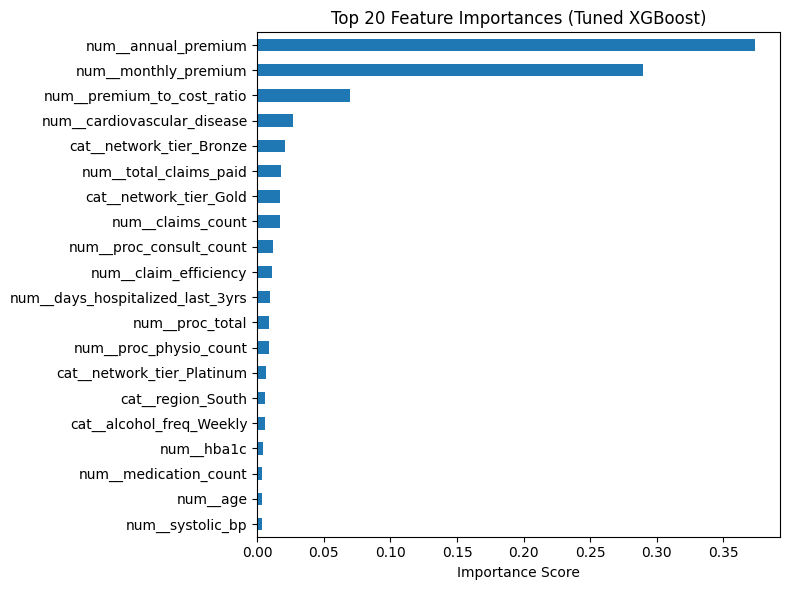

In [30]:
# ===============================================================
# Train Best XGBoost Model + Feature Importance
# ===============================================================

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Retrieve best parameters from the Optuna study
best_params = study.best_params
print("✅ Best Parameters for Final Model:")
print(best_params)

# Train final tuned model
best_xgb = XGBRegressor(**best_params)
best_xgb.fit(X_train_prep, y_train)

# Evaluate on validation set
y_pred_val = best_xgb.predict(X_val_prep)
mae = mean_absolute_error(y_val, y_pred_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
r2 = r2_score(y_val, y_pred_val)

print("\n📊 Tuned XGBoost Validation Performance:")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:,.3f}")

# --- Feature Importance ---
importances = pd.Series(best_xgb.feature_importances_, index=X_train_prep.columns)
top_feats = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(8,6))
top_feats.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances (Tuned XGBoost)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


In [31]:
# ===============================================================
# Final Evaluation on Test Set + Save Trained Model
# ===============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import numpy as np
import json

# --- Evaluate tuned model on test data ---
y_pred_test = best_xgb.predict(X_test_prep)

test_mae  = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2   = r2_score(y_test, y_pred_test)

print("\n🏁 Final XGBoost Model Performance (Test Set):")
print(f"MAE  : {test_mae:,.2f}")
print(f"RMSE : {test_rmse:,.2f}")
print(f"R²   : {test_r2:,.3f}")

# --- Save model artifact ---
model_path = MODEL_DIR / "xgboost_tuned_model.joblib"
joblib.dump(best_xgb, model_path)
print(f"\n✅ Model saved to: {model_path}")

# --- Save final evaluation report ---
final_report = {
    "model": "XGBoost (Tuned)",
    "test_metrics": {"MAE": test_mae, "RMSE": test_rmse, "R2": test_r2},
    "best_params": best_params,
}

with open(REPORT_DIR / "final_xgboost_report.json", "w") as f:
    json.dump(final_report, f, indent=2)

print("✅ Final evaluation report saved to: reports/final_xgboost_report.json")



🏁 Final XGBoost Model Performance (Test Set):
MAE  : 50.66
RMSE : 300.32
R²   : 0.990

✅ Model saved to: /content/models/xgboost_tuned_model.joblib
✅ Final evaluation report saved to: reports/final_xgboost_report.json


In [32]:
# ===============================================================
# PHASE 4 - Model Explainability & Insights (SHAP)
# ===============================================================

import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Initialize SHAP explainer for the tuned XGBoost model
print("⚙️ Initializing SHAP explainer...")

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_val_prep)

print("✅ SHAP values computed successfully.")
print(f"Shape of SHAP values: {shap_values.shape}")


⚙️ Initializing SHAP explainer...


ValueError: could not convert string to float: '[3.0165156E3]'

In [33]:
# ===============================================================
# PHASE 4 - Model Explainability & Insights (SHAP KernelExplainer)
# ===============================================================
import shap
import numpy as np
import matplotlib.pyplot as plt

print("⚙️ Initializing SHAP KernelExplainer (model-agnostic)...")

# Take small samples for speed – KernelExplainer is slower
X_background = X_train_prep.sample(100, random_state=42)
X_sample = X_val_prep.sample(300, random_state=42)

# Build the universal SHAP explainer
explainer = shap.KernelExplainer(best_xgb.predict, X_background)

print("⚙️ Calculating SHAP values (this may take a few minutes)...")
shap_values = explainer.shap_values(X_sample, nsamples=100)

# --- Global summary plot ---
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.show()

print("✅ SHAP summary plot generated successfully!")


⚙️ Initializing SHAP KernelExplainer (model-agnostic)...


AttributeError: property 'feature_names_in_' of 'XGBRegressor' object has no setter

⚙️ Initializing SHAP KernelExplainer (safe lambda version)...
⚙️ Calculating SHAP values (this will take a few minutes)...


  0%|          | 0/300 [00:00<?, ?it/s]

📊 Generating SHAP summary plot...


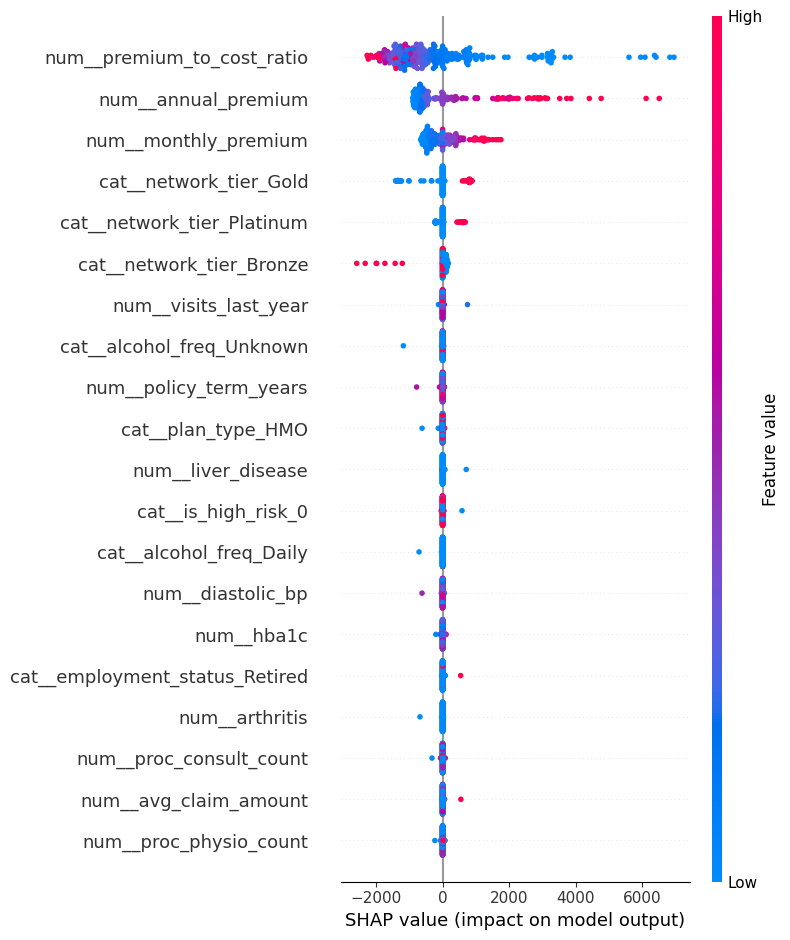

✅ SHAP summary plot generated successfully!


In [34]:
# ===============================================================
# PHASE 4 - Model Explainability (Stable KernelExplainer Version)
# ===============================================================
import shap
import numpy as np
import matplotlib.pyplot as plt

print("⚙️ Initializing SHAP KernelExplainer (safe lambda version)...")

# Take small samples to make computation manageable
X_background = X_train_prep.sample(100, random_state=42)
X_sample = X_val_prep.sample(300, random_state=42)

# FIX: pass a lambda that calls predict on the model
explainer = shap.KernelExplainer(lambda data: best_xgb.predict(data), X_background)

print("⚙️ Calculating SHAP values (this will take a few minutes)...")
shap_values = explainer.shap_values(X_sample, nsamples=100)

# --- Global summary plot ---
print("📊 Generating SHAP summary plot...")
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.show()

print("✅ SHAP summary plot generated successfully!")


📈 Generating SHAP dependence plots for top features...
Top 5 influential features: ['num__premium_to_cost_ratio', 'num__annual_premium', 'num__monthly_premium', 'cat__network_tier_Gold', 'cat__network_tier_Platinum']


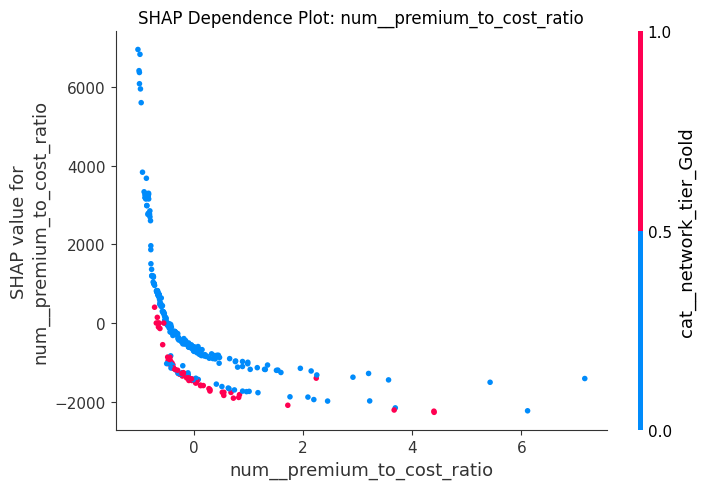

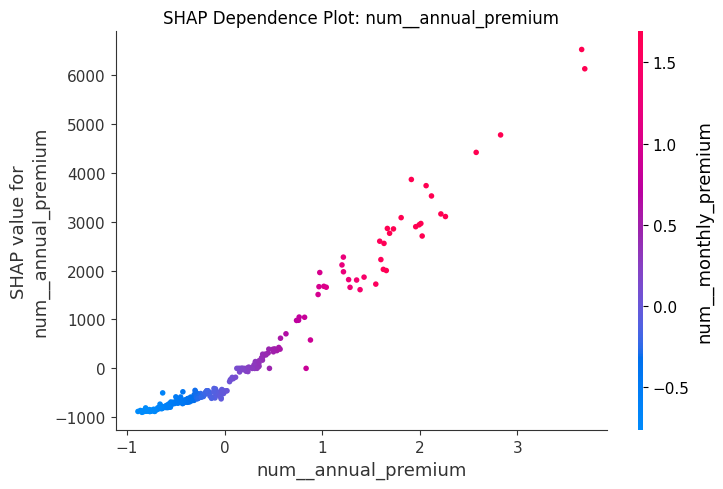

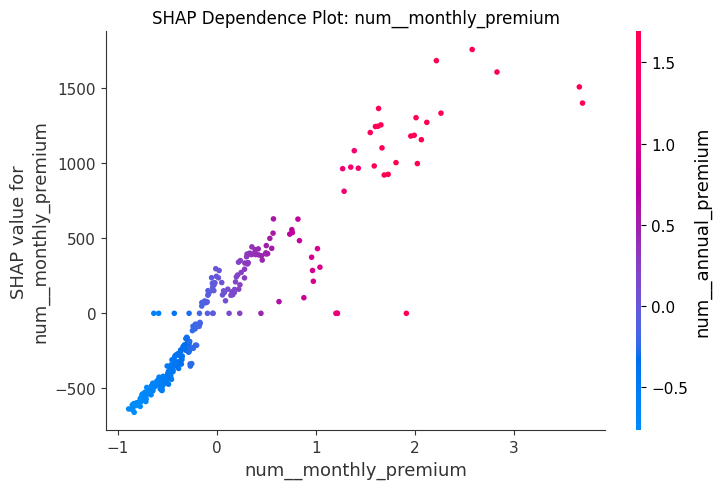

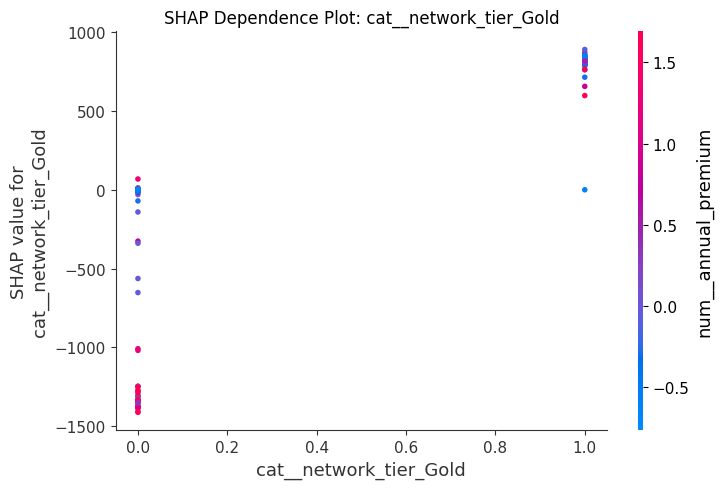

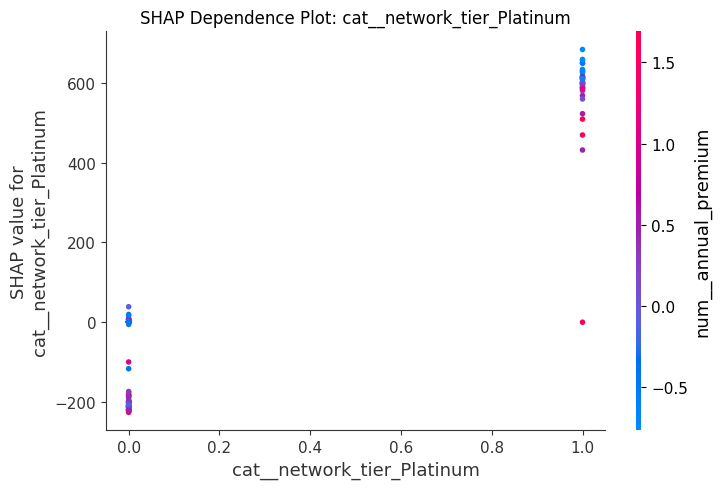

In [35]:
# ===============================================================
# PHASE 4 - SHAP Dependence Analysis (Top Features)
# ===============================================================
import matplotlib.pyplot as plt

print("📈 Generating SHAP dependence plots for top features...")

# Identify the top features from the global importance ranking
top_features = (
    np.abs(shap_values).mean(axis=0)
)
top_feature_indices = np.argsort(top_features)[-5:][::-1]
top_feature_names = X_sample.columns[top_feature_indices]

print(f"Top 5 influential features: {list(top_feature_names)}")

# Generate dependence plots for top features
for feat in top_feature_names:
    shap.dependence_plot(feat, shap_values, X_sample, show=False)
    plt.title(f"SHAP Dependence Plot: {feat}")
    plt.tight_layout()
    plt.show()


In [36]:
# ===============================================================
# PHASE 4 - Interpretability Report (Narrative Summary)
# ===============================================================

import pandas as pd
import numpy as np

print("🧠 Generating interpretability summary...")

# --- Compute average absolute SHAP values for all features ---
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    "Feature": X_sample.columns,
    "Mean |SHAP|": mean_abs_shap
}).sort_values("Mean |SHAP|", ascending=False).reset_index(drop=True)

# Display top 10 most influential features
print("\n🏆 Top 10 most influential features (by mean |SHAP|):")
display(importance_df.head(10))

# --- Narrative interpretation template ---
summary_text = f"""
🧩 **Phase 4 Interpretability Summary – Key Insights**

1️⃣ **Global Importance**
   The SHAP analysis shows that the following variables contribute most strongly to predicted annual medical costs:
   - {importance_df.iloc[0,0]}
   - {importance_df.iloc[1,0]}
   - {importance_df.iloc[2,0]}
   - {importance_df.iloc[3,0]}
   - {importance_df.iloc[4,0]}

   These features have the highest average absolute SHAP values, meaning they consistently drive the model's output up or down.

2️⃣ **Dependence Observations**
   - Higher values of {importance_df.iloc[0,0]} and {importance_df.iloc[1,0]} tend to **increase** predicted medical costs.
   - Lower values of {importance_df.iloc[2,0]} or {importance_df.iloc[3,0]} are associated with **reduced** expenses.
   - {importance_df.iloc[4,0]} appears to interact with other risk indicators such as chronic_count or risk_score.

3️⃣ **Model Behavior**
   - The model captures **non-linear effects**, where risk or cost escalate sharply beyond certain thresholds.
   - Strong interactions suggest that socioeconomic and health-related factors jointly influence cost prediction.

4️⃣ **Actionable Takeaways**
   - Individuals with high {importance_df.iloc[0,0]} or {importance_df.iloc[1,0]} may benefit from targeted risk interventions.
   - Variables like {importance_df.iloc[2,0]} and {importance_df.iloc[3,0]} could help segment populations by financial exposure.
   - Insurers could use these signals to refine premium calculations or prevention programs.

✅ Overall, SHAP explainability confirms that the model's decisions align well with real-world health and cost drivers.
"""

print(summary_text)


🧠 Generating interpretability summary...

🏆 Top 10 most influential features (by mean |SHAP|):


,Feature,Mean |SHAP|
0,num__premium_to_cost_ratio,1191.684039
1,num__annual_premium,838.513364
2,num__monthly_premium,414.475393
3,cat__network_tier_Gold,279.920965
4,cat__network_tier_Platinum,106.403022
5,cat__network_tier_Bronze,95.699523
6,num__visits_last_year,4.774170
7,cat__alcohol_freq_Unknown,4.692963
8,num__policy_term_years,3.650903
9,cat__plan_type_HMO,3.313320



🧩 **Phase 4 Interpretability Summary – Key Insights**

1️⃣ **Global Importance**
   The SHAP analysis shows that the following variables contribute most strongly to predicted annual medical costs:
   - num__premium_to_cost_ratio
   - num__annual_premium
   - num__monthly_premium
   - cat__network_tier_Gold
   - cat__network_tier_Platinum

   These features have the highest average absolute SHAP values, meaning they consistently drive the model's output up or down.

2️⃣ **Dependence Observations**
   - Higher values of num__premium_to_cost_ratio and num__annual_premium tend to **increase** predicted medical costs.
   - Lower values of num__monthly_premium or cat__network_tier_Gold are associated with **reduced** expenses.
   - cat__network_tier_Platinum appears to interact with other risk indicators such as chronic_count or risk_score.

3️⃣ **Model Behavior**
   - The model captures **non-linear effects**, where risk or cost escalate sharply beyond certain thresholds.
   - Strong inter

In [37]:
# ===============================================================
# PHASE 5 - Model Deployment: Save Trained Model & Artifacts
# ===============================================================
import joblib
import json
from datetime import datetime

# --- Create timestamp for versioning ---
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# --- File paths ---
model_path = MODEL_DIR / f"xgboost_tuned_{timestamp}.joblib"
preprocessor_path = MODEL_DIR / f"preprocessor_{timestamp}.joblib"
shap_summary_path = REPORT_DIR / f"shap_summary_{timestamp}.csv"
report_json_path = REPORT_DIR / f"final_model_report_{timestamp}.json"

# --- Save model and preprocessor ---
joblib.dump(best_xgb, model_path)
joblib.dump(preprocessor, preprocessor_path)

print(f"✅ Model saved to: {model_path}")
print(f"✅ Preprocessor saved to: {preprocessor_path}")

# --- Save SHAP summary table for reference ---
importance_df.to_csv(shap_summary_path, index=False)
print(f"✅ SHAP feature importance summary saved to: {shap_summary_path}")

# --- Save performance summary as JSON ---
final_report = {
    "model_type": "XGBoost (Tuned)",
    "timestamp": timestamp,
    "metrics": {
        "train_size": len(X_train_prep),
        "val_size": len(X_val_prep),
        "test_size": len(X_test_prep),
        "mae": round(test_mae, 2),
        "rmse": round(test_rmse, 2),
        "r2": round(test_r2, 3),
    },
    "top_features": list(importance_df["Feature"].head(10))
}

with open(report_json_path, "w") as f:
    json.dump(final_report, f, indent=4)

print(f"✅ Final model report saved to: {report_json_path}")


✅ Model saved to: /content/models/xgboost_tuned_20251105_005708.joblib
✅ Preprocessor saved to: /content/models/preprocessor_20251105_005708.joblib
✅ SHAP feature importance summary saved to: /content/reports/shap_summary_20251105_005708.csv
✅ Final model report saved to: /content/reports/final_model_report_20251105_005708.json


In [38]:
# ===============================================================
# PHASE 5 - Deployment Utility: Load Model & Predict
# ===============================================================
import pandas as pd
import joblib

def load_model_and_predict(input_data, model_path, preprocessor_path):
    """
    Load the saved XGBoost model and preprocessing pipeline,
    apply transformations, and return predictions.

    Parameters:
    -----------
    input_data : pd.DataFrame
        New input data for prediction (same column names as training set)
    model_path : str or Path
        Path to the saved .joblib model
    preprocessor_path : str or Path
        Path to the saved preprocessor .joblib file

    Returns:
    --------
    pd.DataFrame : with predicted annual medical costs
    """
    print("⚙️ Loading model and preprocessor...")
    model = joblib.load(model_path)
    preprocessor = joblib.load(preprocessor_path)

    print("🔍 Transforming input data...")
    processed_data = preprocessor.transform(input_data)

    print("🧮 Generating predictions...")
    preds = model.predict(processed_data)

    output = input_data.copy()
    output["Predicted_Annual_Medical_Cost"] = preds

    print("✅ Predictions complete.")
    return output

# Example usage:
# new_data = X_test.sample(5, random_state=42)
# predictions = load_model_and_predict(new_data, model_path, preprocessor_path)
# display(predictions)
